# Experimento 1

In [2]:
import sys, os, duckdb
import pandas as pd

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from config.config import V2_DB

con = duckdb.connect(V2_DB)

VARS_DESCARTADAS = (
    'CLOUD_BT', 'CLOUD_BT_MAX', 'CLOUD_BT_MIN',
    'CLOUD_TT', 'CLOUD_TT_MAX', 'CLOUD_TT_MIN',
    'GWM_HEIGHT', 'GWM_HEIGHT_ANOMALY',
    'IMERG_PRECLIQUID_PROB', 'IMERG_PRECTOT', 'IMERG_PRECTOT_COUNT',
    'LWLAND', 'ORIGINAL_ALLSKY_SFC_LW_DWN', 'ORIGINAL_ALLSKY_SFC_SW_DWN',
    'ORIGINAL_CLRSKY_SFC_LW_DWN', 'ORIGINAL_CLRSKY_SFC_SW_DWN',
    'PRMC', 'PRMC_PRCNTL', 'RZMC', 'RZMC_PRCNTL',
    'SFMC', 'SWLAND', 'SZA'
)
vars_excluidas_sql = ", ".join([f"'{v}'" for v in VARS_DESCARTADAS])

vars_clima = con.execute(f"""
    SELECT DISTINCT id_variable
    FROM working.climatologia
    WHERE id_variable NOT IN ({vars_excluidas_sql})
    ORDER BY id_variable
""").df()['id_variable'].tolist()

pivot_cols = ",\n    ".join([
    f"AVG(CASE WHEN id_variable = '{v}' THEN resultado_numerico END) AS \"{v}\""
    for v in vars_clima
])

df = con.execute(f"""
    WITH clima_pivot AS (
        SELECT
            id_clave_inc,
            {pivot_cols}
        FROM working.climatologia
        WHERE id_variable NOT IN ({vars_excluidas_sql})
        GROUP BY id_clave_inc
    ),
    demo_total AS (
        SELECT
            id_cvegeo,
            anio,
            SUM(pob_total) AS pob_total
        FROM working.demografia
        GROUP BY id_cvegeo, anio
    )
    SELECT
        i.id_clave_inc,
        i.latitud,
        i.longitud,
        i.anio,
        EXTRACT(MONTH FROM i.fecha_inicio)::INTEGER AS mes,
        EXTRACT(DOW   FROM i.fecha_inicio)::INTEGER AS dia_semana,
        i.tipo_de_incendio,
        v.tipo_de_vegetacion,
        v.regimen_del_fuego,
        m.nombre_municipio,
        o.hora_deteccion,
        dem.pob_total,
        d.tamanio,
        cp.*
    FROM working.incendios i
    LEFT JOIN working.vegetacion   v   ON i.id_vegetacion = v.id_vegetacion
    LEFT JOIN working.municipios   m   ON i.id_cvegeo     = m.id_cvegeo
    LEFT JOIN working.operaciones  o   ON i.id_clave_inc  = o.id_clave_inc
    LEFT JOIN working.danos        d   ON i.id_clave_inc  = d.id_clave_inc
    LEFT JOIN demo_total           dem ON i.id_cvegeo     = dem.id_cvegeo
                                      AND i.anio          = dem.anio
    LEFT JOIN clima_pivot          cp  ON i.id_clave_inc  = cp.id_clave_inc
""").df()

con.close()

df = df.loc[:, ~df.columns.duplicated()]

# Convertir hora_deteccion a minutos desde medianoche
df['hora_deteccion'] = pd.to_datetime(df['hora_deteccion'].astype(str), errors='coerce')
df['hora_deteccion_min'] = (
    df['hora_deteccion'].dt.hour * 60 +
    df['hora_deteccion'].dt.minute
)
df = df.drop(columns=['hora_deteccion'])

print("Pivoteo listo.")

Pivoteo listo.


C:\Users\jrf24\AppData\Local\Temp\ipykernel_15480\2456706728.py:82: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['hora_deteccion'] = pd.to_datetime(df['hora_deteccion'].astype(str), errors='coerce')


In [3]:
pd.set_option('display.max_columns', None)
print(df.head())


  id_clave_inc    latitud    longitud  anio  mes  dia_semana tipo_de_incendio  \
0   17-15-1441  19.399694 -100.149559  2017    6           2      superficial   
1   17-15-1445  19.187500 -100.104362  2017    6           3      superficial   
2   17-15-1446  19.291252  -98.759644  2017    6           4      superficial   
3   18-15-0041  19.235056  -99.833138  2018    1           3      superficial   
4   18-15-0045  19.678417  -99.537476  2018    1           4      superficial   

      tipo_de_vegetacion regimen_del_fuego  nombre_municipio  pob_total  \
0  bosque de pino-encino          adaptado  villa de allende    54002.0   
1         bosque de pino          adaptado    valle de bravo    65061.0   
2  bosque de pino-encino          adaptado            chalco   375644.0   
3       bosque de oyamel          sensible      zinacantepec   202277.0   
4  bosque de encino-pino          adaptado  villa del carbon    50885.0   

           tamanio id_clave_inc_1  AIRMASS  ALLSKY_KT  ALLSKY_

In [4]:
# Eliminar columna duplicada
df = df.drop(columns=['id_clave_inc_1'], errors='ignore')

# Mapear target
mapa_tamanio = {
    '0 a 5 hectareas'       : '1_0_a_5',
    '6 a 10 hectareas'      : '2_6_a_20',
    '11 a 20 hectareas'     : '2_6_a_20',
    '21 a 50 hectareas'     : '3_21_a_50',
    '51 a 100 hectareas'    : '4_mas_de_50',
    'mayor a 100 hectareas' : '4_mas_de_50',
}
df['tamanio_modelo'] = df['tamanio'].map(mapa_tamanio)
df = df.drop(columns=['tamanio'])

print("Pivoteo listo.")

Pivoteo listo.


In [5]:
# ================================================================
# INSPECCIÓN — nulos y duplicados
# ================================================================
# Duplicados
print(f"Filas duplicadas : {df.duplicated().sum()}")
print(f"IDs duplicados   : {df['id_clave_inc'].duplicated().sum()}")

# Nulos por columna
nulos = df.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
print(f"\nColumnas con nulos ({len(nulos)} de {df.shape[1]}):")
print(nulos.to_string())

# Nulos por fila
nulos_por_fila = df.isnull().sum(axis=1)
print(f"\nFilas con al menos 1 nulo : {(nulos_por_fila > 0).sum()}")
print(f"Filas con más de 5 nulos  : {(nulos_por_fila > 5).sum()}")
print(f"Filas con más de 10 nulos : {(nulos_por_fila > 10).sum()}")

print("\nInspección lista.")

Filas duplicadas : 0
IDs duplicados   : 0

Columnas con nulos (19 de 135):
latitud               174
longitud              174
EVLAND                105
TSOIL5                105
EVPTRNS               105
FRSNO                 105
GWETPROF              105
GWETROOT              105
PRECSNOLAND           105
SNODP                 105
TSOIL1                105
TSURF                 105
TSOIL2                105
TSOIL3                105
TSOIL4                105
TSOIL6                105
CLRSKY_NKT             33
hora_deteccion_min      3
NDMI                    2

Filas con al menos 1 nulo : 212
Filas con más de 5 nulos  : 105
Filas con más de 10 nulos : 105

Inspección lista.


In [6]:
mask_suelo  = df['TSOIL1'].isnull()
mask_coords = df['latitud'].isnull()

print(f"Filas con nulos de suelo Y sin coordenadas: {(mask_suelo & mask_coords).sum()}")

print("\nAños — nulos de suelo:")
print(df[mask_suelo]['anio'].value_counts().sort_index())

print("\nAños — sin coordenadas:")
print(df[mask_coords]['anio'].value_counts().sort_index())

print("\nTarget — nulos de suelo:")
print(df[mask_suelo]['tamanio_modelo'].value_counts())

print("\nTarget — sin coordenadas:")
print(df[mask_coords]['tamanio_modelo'].value_counts())

print("\nDiagnóstico listo.")

Filas con nulos de suelo Y sin coordenadas: 105

Años — nulos de suelo:
anio
2015    36
2016    69
Name: count, dtype: int64

Años — sin coordenadas:
anio
2015    38
2016    80
2017     8
2018    10
2019     1
2020    11
2021     3
2022     7
2023     7
2024     7
2025     2
Name: count, dtype: int64

Target — nulos de suelo:
tamanio_modelo
1_0_a_5        88
2_6_a_20       13
4_mas_de_50     3
3_21_a_50       1
Name: count, dtype: int64

Target — sin coordenadas:
tamanio_modelo
1_0_a_5        110
2_6_a_20        35
4_mas_de_50     21
3_21_a_50        8
Name: count, dtype: int64

Diagnóstico listo.


In [7]:
total        = len(df)
a_eliminar   = df['latitud'].isnull().sum()
quedan       = total - a_eliminar
print(f"Total          : {total}")
print(f"A eliminar     : {a_eliminar}")
print(f"Quedan         : {quedan}  ({quedan/total*100:.1f}%)")

Total          : 12703
A eliminar     : 174
Quedan         : 12529  (98.6%)


In [8]:
# ================================================================
# LIMPIEZA — eliminación de filas con nulos críticos
# ================================================================

# Eliminar filas sin coordenadas (incluye las 105 de suelo)
df = df[df['latitud'].notnull()].copy()

# Imputar nulos menores con mediana
for col in ['CLRSKY_NKT', 'hora_deteccion_min', 'NDMI']:
    df[col] = df[col].fillna(df[col].median())

# Verificación
nulos_restantes = df.isnull().sum().sum()
print(f"Shape final     : {df.shape}")
print(f"Nulos restantes : {nulos_restantes}")

print("\nLimpieza lista.")

Shape final     : (12529, 135)
Nulos restantes : 0

Limpieza lista.


In [9]:

cols_categoricas = ['tipo_de_incendio', 'tipo_de_vegetacion', 
                    'regimen_del_fuego', 'nombre_municipio']

for col in cols_categoricas:
    df[col] = df[col].str.strip()
    df[col] = df[col].str.replace('\n', ' ')
    df[col] = df[col].str.replace('\t', ' ')
    df[col] = df[col].str.replace(r'\s+', ' ', regex=True)

# Unificar categorías equivalentes
df['tipo_de_vegetacion'] = df['tipo_de_vegetacion'].str.replace(
    'bosque de encino-pino', 'bosque de pino-encino'
)

# Verificación
print(df['tipo_de_vegetacion'].value_counts().to_string())
print("\nLimpieza de categóricas lista.")

tipo_de_vegetacion
bosque de pino                                              4669
bosque de pino-encino                                       4040
bosque de encino                                            2141
bosque de oyamel                                             927
matorral crasicaule                                          299
bosque mesofilo de montana                                   165
bosque cultivado                                              79
bosque de tascate                                             62
bosque de cedro                                               57
selva baja caducifolia                                        51
pradera de alta montana                                       18
bosque inducido                                                6
pastizal natural                                               4
pastizal halofilo                                              3
tular                                                          2
matorr

In [10]:
cols_categoricas = ['tipo_de_incendio', 'tipo_de_vegetacion', 'regimen_del_fuego', 'nombre_municipio']

for col in cols_categoricas:
    print(f"\n{col}:")
    print(df[col].value_counts().to_string())


tipo_de_incendio:
tipo_de_incendio
superficial    12435
mixto             74
de copa           18
subterraneo        2

tipo_de_vegetacion:
tipo_de_vegetacion
bosque de pino                                              4669
bosque de pino-encino                                       4040
bosque de encino                                            2141
bosque de oyamel                                             927
matorral crasicaule                                          299
bosque mesofilo de montana                                   165
bosque cultivado                                              79
bosque de tascate                                             62
bosque de cedro                                               57
selva baja caducifolia                                        51
pradera de alta montana                                       18
bosque inducido                                                6
pastizal natural                                            

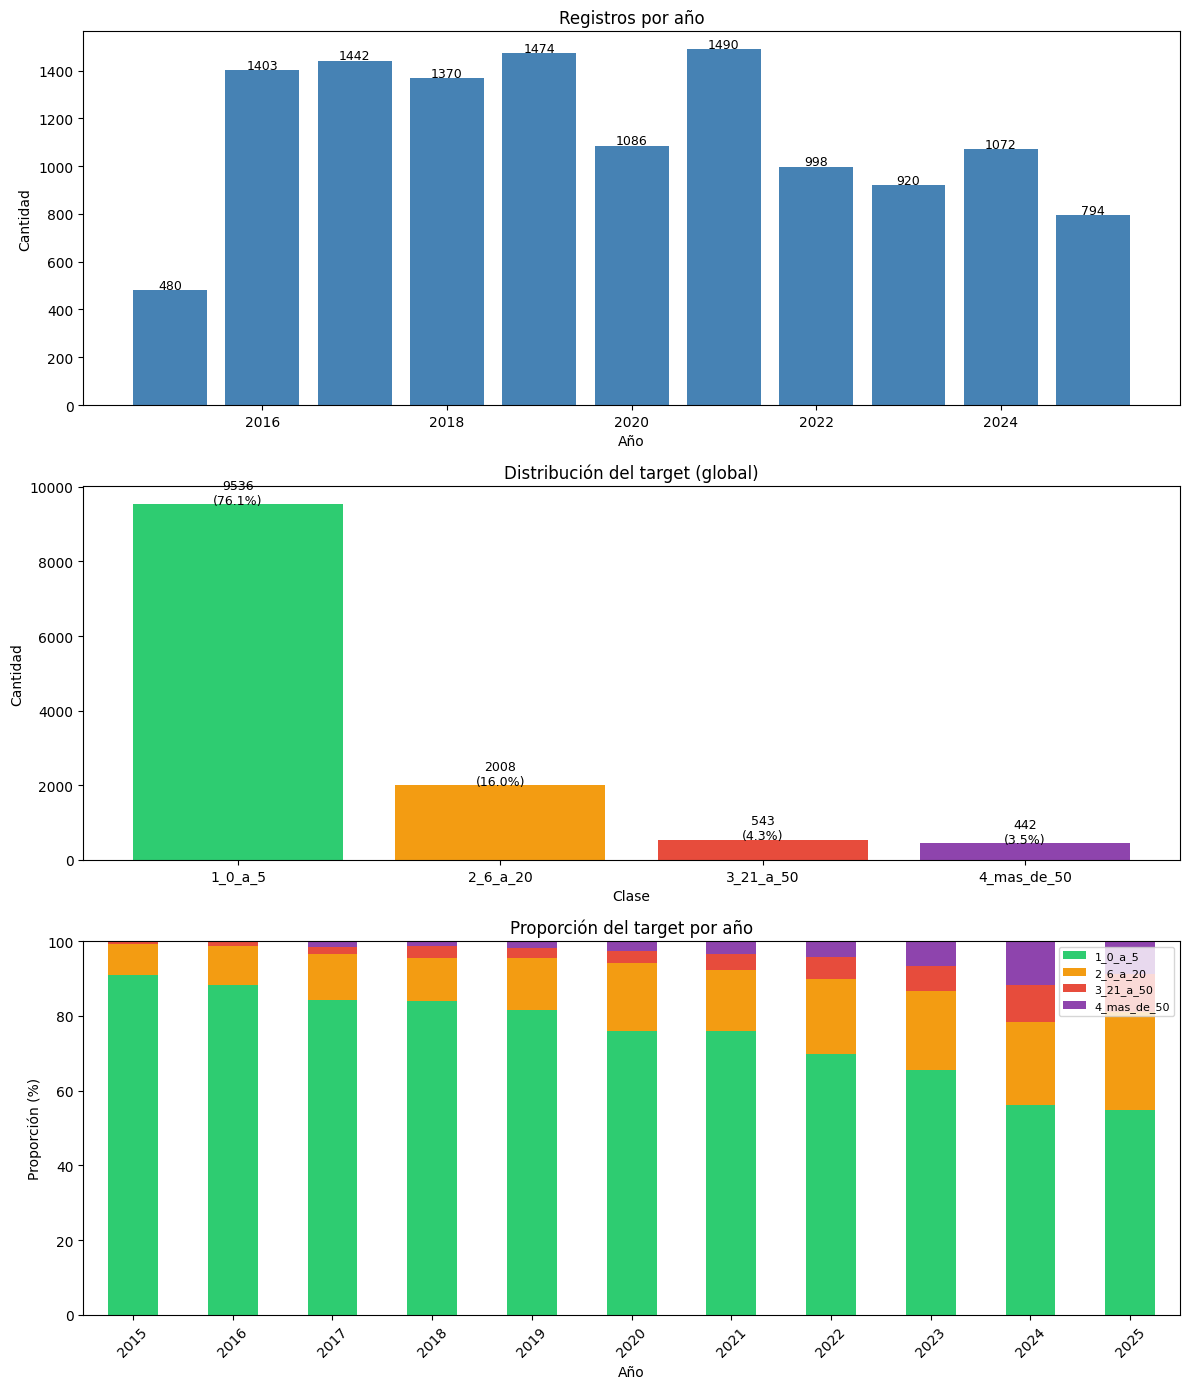

Gráfica guardada.


In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(12, 14))

# --- Gráfica 1: Registros por año ---
conteo_anio = df.groupby('anio').size()
axes[0].bar(conteo_anio.index, conteo_anio.values, color='steelblue')
axes[0].set_title('Registros por año')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Cantidad')
for i, (anio, val) in enumerate(conteo_anio.items()):
    axes[0].text(anio, val + 5, str(val), ha='center', fontsize=9)

# --- Gráfica 2: Distribución del target global ---
dist = df['tamanio_modelo'].value_counts().sort_index()
colores = ['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad']
axes[1].bar(dist.index, dist.values, color=colores)
axes[1].set_title('Distribución del target (global)')
axes[1].set_xlabel('Clase')
axes[1].set_ylabel('Cantidad')
for i, (clase, val) in enumerate(dist.items()):
    axes[1].text(i, val + 10, f'{val}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=9)

# --- Gráfica 3: Target por año (proporciones) ---
target_anio = df.groupby(['anio', 'tamanio_modelo']).size().unstack(fill_value=0)
target_anio_pct = target_anio.div(target_anio.sum(axis=1), axis=0) * 100
target_anio_pct.plot(kind='bar', stacked=True, ax=axes[2], color=colores)
axes[2].set_title('Proporción del target por año')
axes[2].set_xlabel('Año')
axes[2].set_ylabel('Proporción (%)')
axes[2].legend(loc='upper right', fontsize=8)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('eda_target.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfica guardada.")


Para el split mi recomendación sería:

Train: 2015 — 2022 (~10,000 registros)
Validation: 2023 (~998 registros)
Test: 2024 — 2025 (~1,866 registros)

In [12]:
# ================================================================
# SPLIT TEMPORAL
# ================================================================

train = df[df['anio'] <= 2022].copy()
val   = df[df['anio'] == 2023].copy()
test  = df[df['anio'] >= 2024].copy()

# Verificación
print(f"Train : {len(train):>5} registros  ({train['anio'].min()}-{train['anio'].max()})")
print(f"Val   : {len(val):>5} registros  ({val['anio'].min()}-{val['anio'].max()})")
print(f"Test  : {len(test):>5} registros  ({test['anio'].min()}-{test['anio'].max()})")

print(f"\nProporción train : {len(train)/len(df)*100:.1f}%")
print(f"Proporción val   : {len(val)/len(df)*100:.1f}%")
print(f"Proporción test  : {len(test)/len(df)*100:.1f}%")

# Distribución del target en cada split
for nombre, split in [('Train', train), ('Val', val), ('Test', test)]:
    print(f"\nTarget — {nombre}:")
    dist = split['tamanio_modelo'].value_counts().sort_index()
    for clase, cnt in dist.items():
        print(f"   {clase:<20} {cnt:>4}  ({cnt/len(split)*100:.1f}%)")

print("\nSplit listo.")

Train :  9743 registros  (2015-2022)
Val   :   920 registros  (2023-2023)
Test  :  1866 registros  (2024-2025)

Proporción train : 77.8%
Proporción val   : 7.3%
Proporción test  : 14.9%

Target — Train:
   1_0_a_5              7897  (81.1%)
   2_6_a_20             1367  (14.0%)
   3_21_a_50             292  (3.0%)
   4_mas_de_50           187  (1.9%)

Target — Val:
   1_0_a_5               602  (65.4%)
   2_6_a_20              196  (21.3%)
   3_21_a_50              61  (6.6%)
   4_mas_de_50            61  (6.6%)

Target — Test:
   1_0_a_5              1037  (55.6%)
   2_6_a_20              445  (23.8%)
   3_21_a_50             190  (10.2%)
   4_mas_de_50           194  (10.4%)

Split listo.


In [13]:
# ================================================================
# SPLIT TEMPORAL
# ================================================================

train = df[df['anio'] <= 2022].copy()
val   = df[df['anio'] == 2023].copy()
test  = df[df['anio'] >= 2024].copy()

# Verificación
print(f"Train : {len(train):>5} registros  ({train['anio'].min()}-{train['anio'].max()})")
print(f"Val   : {len(val):>5} registros  ({val['anio'].min()}-{val['anio'].max()})")
print(f"Test  : {len(test):>5} registros  ({test['anio'].min()}-{test['anio'].max()})")
print("\nSplit listo.")

Train :  9743 registros  (2015-2022)
Val   :   920 registros  (2023-2023)
Test  :  1866 registros  (2024-2025)

Split listo.


Precaución: 3 variables constantes descartadas.
Climáticas procesadas  : 119
Grupos encontrados     : 33
Variables eliminadas   : 86


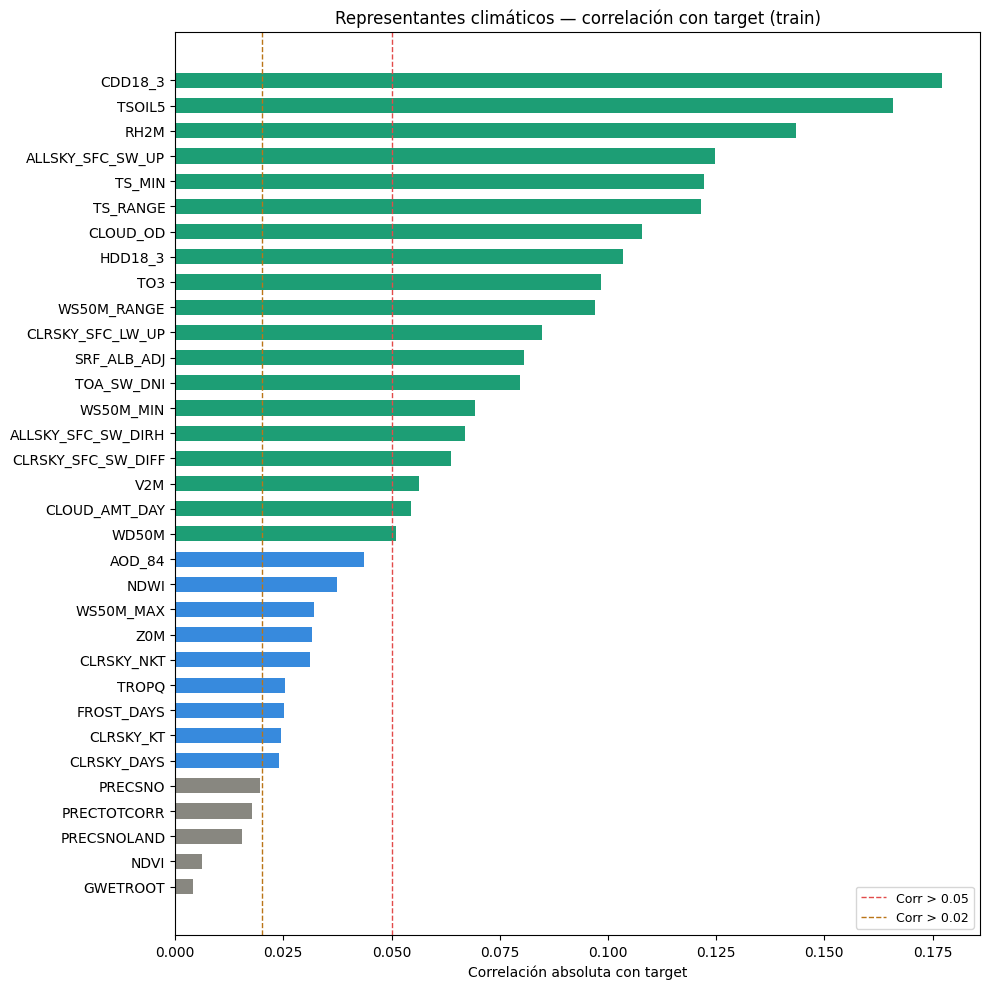


Pearson listo.


In [14]:
from scipy.cluster import hierarchy
from scipy.spatial.distance import pdist
from sklearn.preprocessing import OrdinalEncoder
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ================================================================
# PEARSON — CLUSTERING DE CORRELACIÓN (solo sobre train)
# ================================================================

TARGET_COL   = 'tamanio_modelo'
cols_clima   = [c for c in train.columns if c in vars_clima]

# Encoding ordinal del target
orden_clases = [['1_0_a_5', '2_6_a_20', '3_21_a_50', '4_mas_de_50']]
enc_target   = OrdinalEncoder(categories=orden_clases)
y_ord        = enc_target.fit_transform(train[[TARGET_COL]]).ravel()

# Preparar matriz climática solo del train
df_clima = train[cols_clima].copy()
df_clima = df_clima.dropna(axis=1, how='all')
df_clima = df_clima.fillna(df_clima.median())

desviacion   = df_clima.std()
cols_validas = desviacion[desviacion > 0].index
if len(cols_validas) < len(df_clima.columns):
    eliminadas = len(df_clima.columns) - len(cols_validas)
    print(f"Precaución: {eliminadas} variables constantes descartadas.")
df_clima = df_clima[cols_validas]

# Clustering jerárquico
dist_condensada = pdist(df_clima.values.T, metric='correlation')
dist_condensada = np.nan_to_num(dist_condensada, nan=0.0, posinf=1.0, neginf=-1.0)
dist_condensada = np.clip(dist_condensada, 0, None)

linkage        = hierarchy.ward(dist_condensada)
cluster_labels = hierarchy.fcluster(linkage, t=0.5, criterion='distance')

grupos_df = pd.DataFrame({
    'variable': df_clima.columns,
    'grupo'   : cluster_labels
})

representantes = []
log_grupos     = []

for g in sorted(grupos_df['grupo'].unique()):
    vars_grupo  = grupos_df[grupos_df['grupo'] == g]['variable'].tolist()
    corr_target = {}
    for v in vars_grupo:
        try:
            corr_val = abs(np.corrcoef(df_clima[v], y_ord)[0, 1])
            corr_target[v] = corr_val if not np.isnan(corr_val) else 0.0
        except:
            corr_target[v] = 0.0

    mejor = max(corr_target, key=corr_target.get)
    representantes.append(mejor)
    log_grupos.append({
        'grupo'        : g,
        'n_vars'       : len(vars_grupo),
        'representante': mejor,
        'corr_target'  : round(corr_target[mejor], 4),
        'descartadas'  : ', '.join([v for v in vars_grupo if v != mejor])
    })

df_log = (pd.DataFrame(log_grupos)
            .sort_values('corr_target', ascending=False)
            .reset_index(drop=True))

cols_clima_reducidas = representantes.copy()

print(f"Climáticas procesadas  : {len(df_clima.columns)}")
print(f"Grupos encontrados     : {len(representantes)}")
print(f"Variables eliminadas   : {len(df_clima.columns) - len(representantes)}")

# ================================================================
# GRÁFICA
# ================================================================
colores = [
    '#1D9E75' if v > 0.05 else '#378ADD' if v > 0.02 else '#888780'
    for v in df_log['corr_target']
]
fig, ax = plt.subplots(figsize=(10, 10))
ax.barh(df_log['representante'][::-1], df_log['corr_target'][::-1],
        color=colores[::-1], height=0.6)
ax.set_title('Representantes climáticos — correlación con target (train)')
ax.set_xlabel('Correlación absoluta con target')
ax.axvline(x=0.05, color='#E24B4A', linestyle='--', linewidth=1, label='Corr > 0.05')
ax.axvline(x=0.02, color='#BA7517', linestyle='--', linewidth=1, label='Corr > 0.02')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("\nPearson listo.")

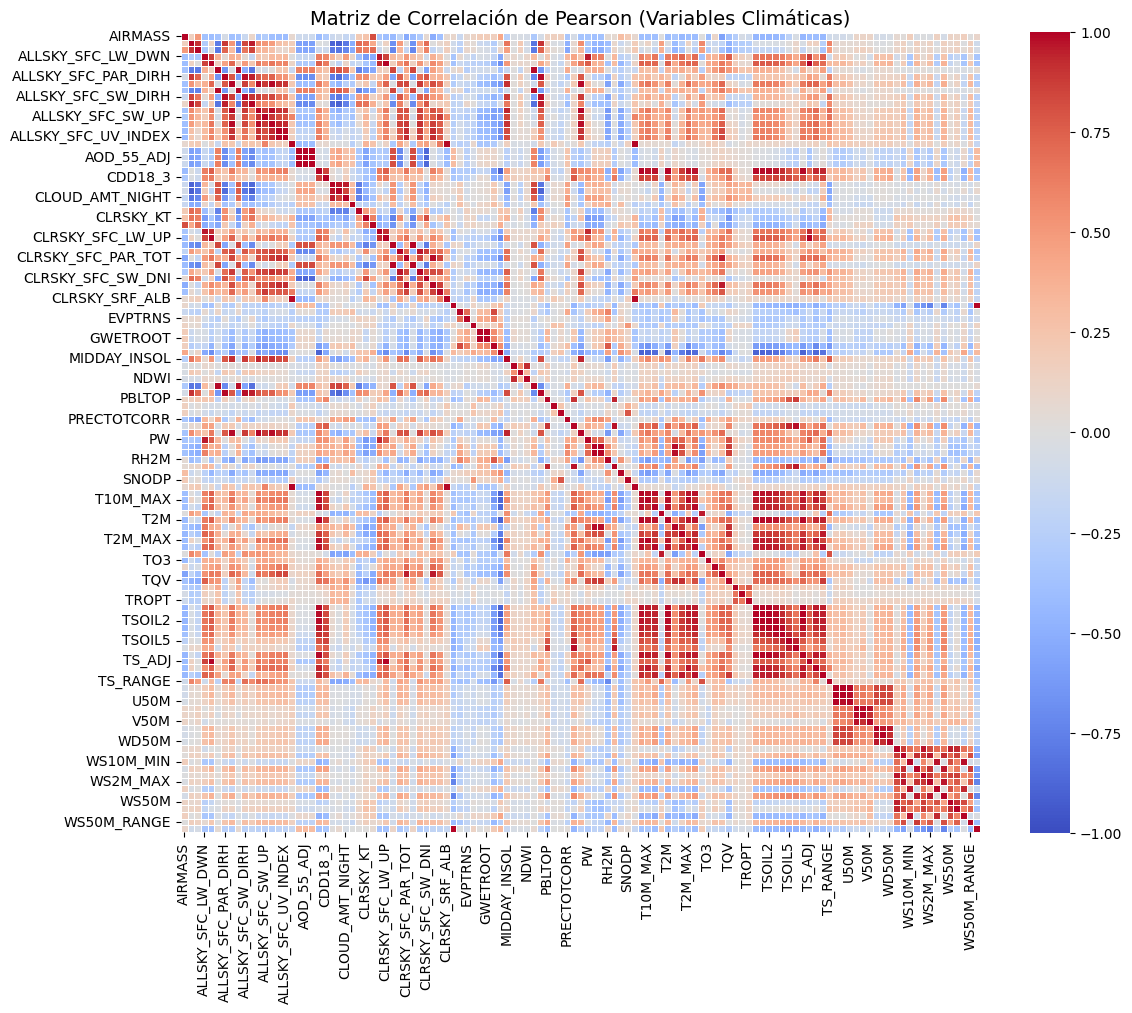

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt


# Calculamos la matriz de correlación de las variables climáticas originales
matriz_corr = df_clima.corr(method='pearson')

fig, ax = plt.subplots(figsize=(12, 10))

# Generamos el Heatmap
sns.heatmap(matriz_corr, 
            cmap='coolwarm',  # Colores: Azul (negativa), Blanco (cero), Rojo (positiva)
            vmin=-1, vmax=1,  # Rango de Pearson
            annot=False,      # Apagamos los números porque son muchas variables
            square=True, 
            linewidths=.5)

ax.set_title('Matriz de Correlación de Pearson (Variables Climáticas)', fontsize=14)
plt.tight_layout()
plt.show()

In [16]:

# Quitar representantes con corr < 0.02
cols_clima_finales = df_log[df_log['corr_target'] >= 0.02]['representante'].tolist()

print(f"Climáticas antes : {len(cols_clima_reducidas)}")
print(f"Climáticas finales: {len(cols_clima_finales)}")

# Columnas no climáticas
cols_no_clima = ['latitud', 'longitud', 'mes', 'dia_semana', 'tipo_de_incendio',
                 'tipo_de_vegetacion', 'regimen_del_fuego', 'nombre_municipio',
                 'pob_total', 'hora_deteccion_min']

ID_COL     = 'id_clave_inc'
TARGET_COL = 'tamanio_modelo'

cols_features = cols_no_clima + cols_clima_finales

# Separar X e y
X_train = train[cols_features].copy()
y_train = train[TARGET_COL]

X_val   = val[cols_features].copy()
y_val   = val[TARGET_COL]

X_test  = test[cols_features].copy()
y_test  = test[TARGET_COL]

print(f"\nX_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")

print("\nFeatures listas.")

Climáticas antes : 33
Climáticas finales: 28

X_train : (9743, 38)
X_val   : (920, 38)
X_test  : (1866, 38)

Features listas.


In [17]:
from sklearn.preprocessing import OrdinalEncoder

# ================================================================
# ENCODING DE CATEGÓRICAS
# ================================================================

cols_categoricas = ['tipo_de_incendio', 'tipo_de_vegetacion',
                    'regimen_del_fuego', 'nombre_municipio']

enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# Aprender solo del train
X_train[cols_categoricas] = enc.fit_transform(X_train[cols_categoricas])

# Aplicar a val y test sin reajustar
X_val[cols_categoricas]   = enc.transform(X_val[cols_categoricas])
X_test[cols_categoricas]  = enc.transform(X_test[cols_categoricas])

print("Tipos de datos después del encoding:")
print(X_train.dtypes.value_counts())
print("\nEncoding listo.")

Tipos de datos después del encoding:
float64    34
float32     2
int32       2
Name: count, dtype: int64

Encoding listo.


Modelo entrenado.

--- Validación ---
              precision    recall  f1-score   support

     1_0_a_5       0.67      0.97      0.79       602
    2_6_a_20       0.15      0.03      0.04       196
   3_21_a_50       0.00      0.00      0.00        61
 4_mas_de_50       0.27      0.07      0.11        61

    accuracy                           0.64       920
   macro avg       0.27      0.26      0.24       920
weighted avg       0.49      0.64      0.53       920



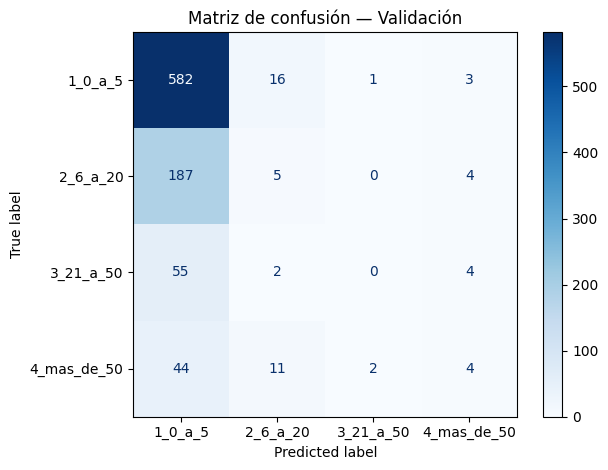

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

clf = RandomForestClassifier(
    n_estimators    = 300,
    max_depth       = None,
    min_samples_leaf= 5,
    class_weight    = 'balanced',
    random_state    = 42,
    n_jobs          = -1
)

clf.fit(X_train, y_train)
print("Modelo entrenado.")

y_pred_val = clf.predict(X_val)

print("\n--- Validación ---")
print(classification_report(y_val, y_pred_val))

cm  = confusion_matrix(y_val, y_pred_val, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap='Blues')
plt.title('Matriz de confusión — Validación')
plt.tight_layout()
plt.show()

C:\Users\jrf24\AppData\Local\Temp\ipykernel_15480\22513978.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


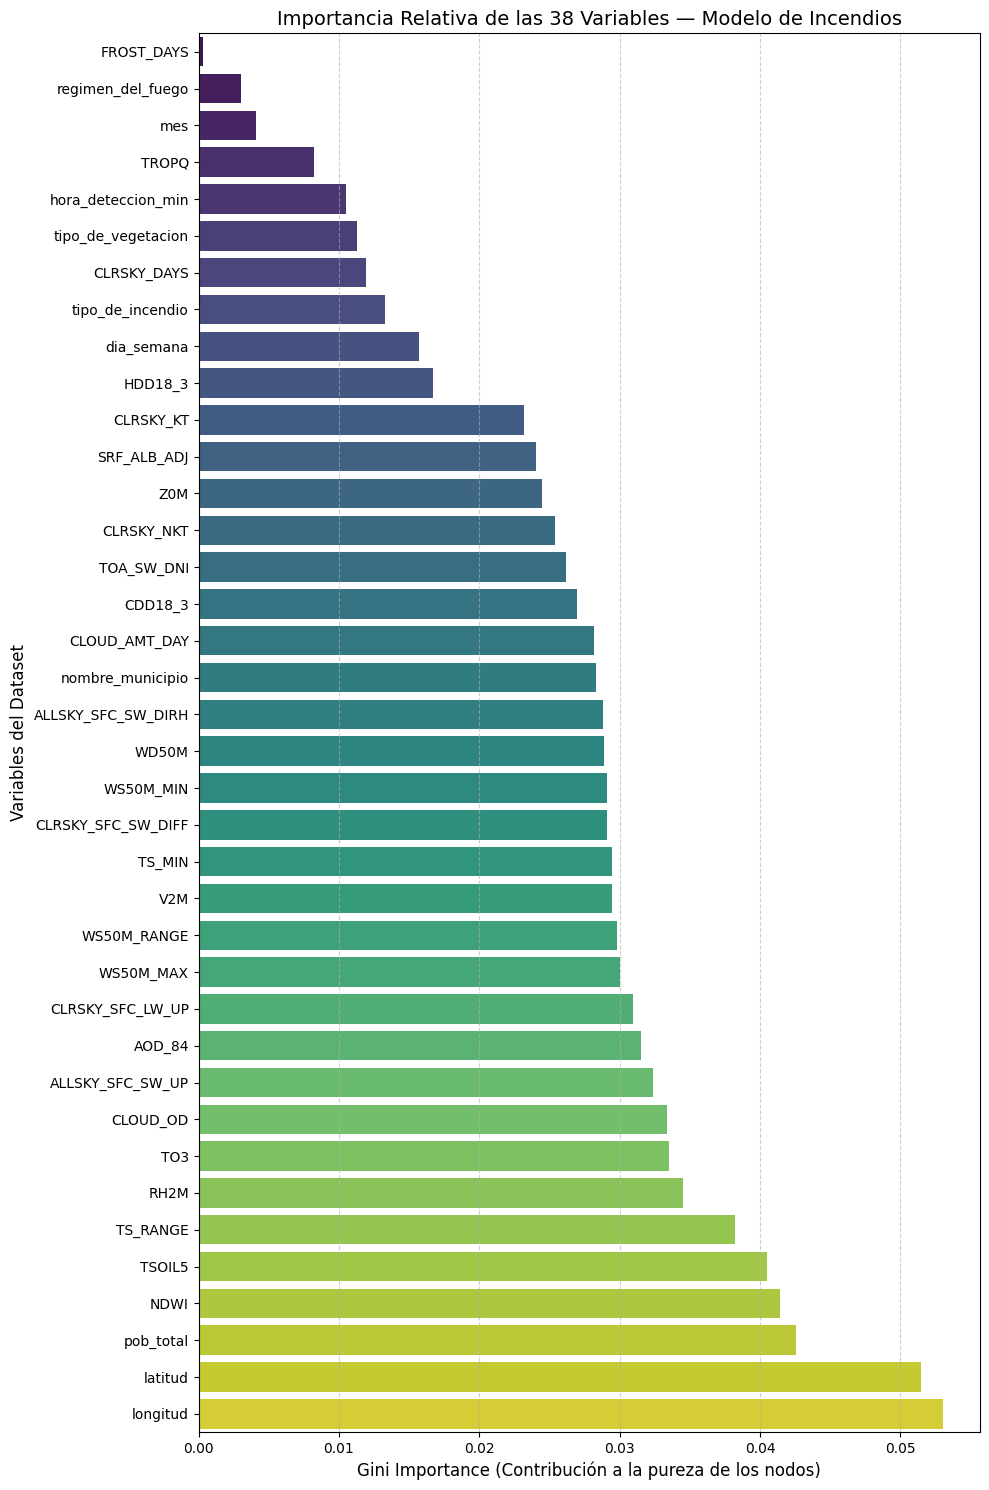


--- Listado Completo de Importancias ---
              Variable  Importancia
1             longitud     0.053023
0              latitud     0.051443
8            pob_total     0.042588
30                NDWI     0.041449
11              TSOIL5     0.040514
15            TS_RANGE     0.038247
12                RH2M     0.034505
18                 TO3     0.033531
16            CLOUD_OD     0.033395
13    ALLSKY_SFC_SW_UP     0.032363
29              AOD_84     0.031523
20    CLRSKY_SFC_LW_UP     0.030983
31           WS50M_MAX     0.030007
19         WS50M_RANGE     0.029775
26                 V2M     0.029488
14              TS_MIN     0.029464
25  CLRSKY_SFC_SW_DIFF     0.029118
23           WS50M_MIN     0.029069
28               WD50M     0.028876
24  ALLSKY_SFC_SW_DIRH     0.028788
7     nombre_municipio     0.028347
27       CLOUD_AMT_DAY     0.028199
10             CDD18_3     0.026992
22          TOA_SW_DNI     0.026154
33          CLRSKY_NKT     0.025418
32                 Z0M

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

importances = clf.feature_importances_
feature_names = X_train.columns

# 2. Crear un DataFrame ordenado
df_importance = pd.DataFrame({
    'Variable': feature_names,
    'Importancia': importances
}).sort_values(by='Importancia', ascending=True) 

plt.figure(figsize=(10, 15)) 

sns.barplot(
    x='Importancia', 
    y='Variable', 
    data=df_importance, 
    palette='viridis'
)

plt.title('Importancia Relativa de las 38 Variables — Modelo de Incendios', fontsize=14)
plt.xlabel('Gini Importance (Contribución a la pureza de los nodos)', fontsize=12)
plt.ylabel('Variables del Dataset', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# 4. Mostrar la tabla completa en consola por si necesitas los valores exactos
pd.set_option('display.max_rows', None) 
print("\n--- Listado Completo de Importancias ---")
print(df_importance.sort_values(by='Importancia', ascending=False))

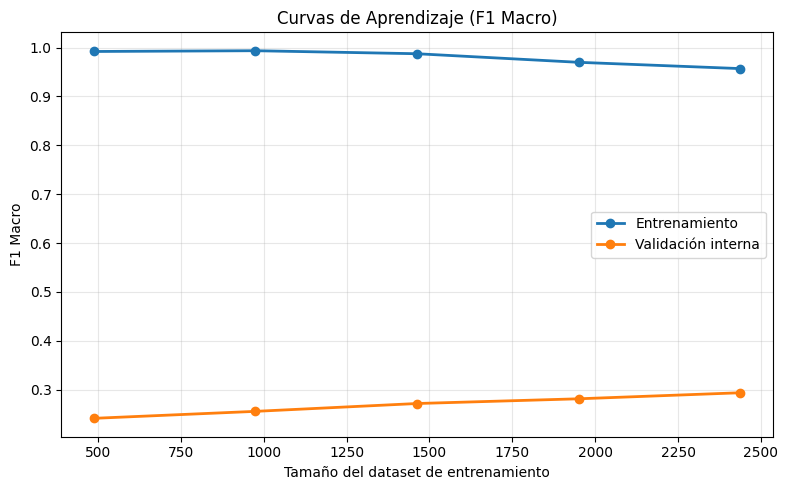

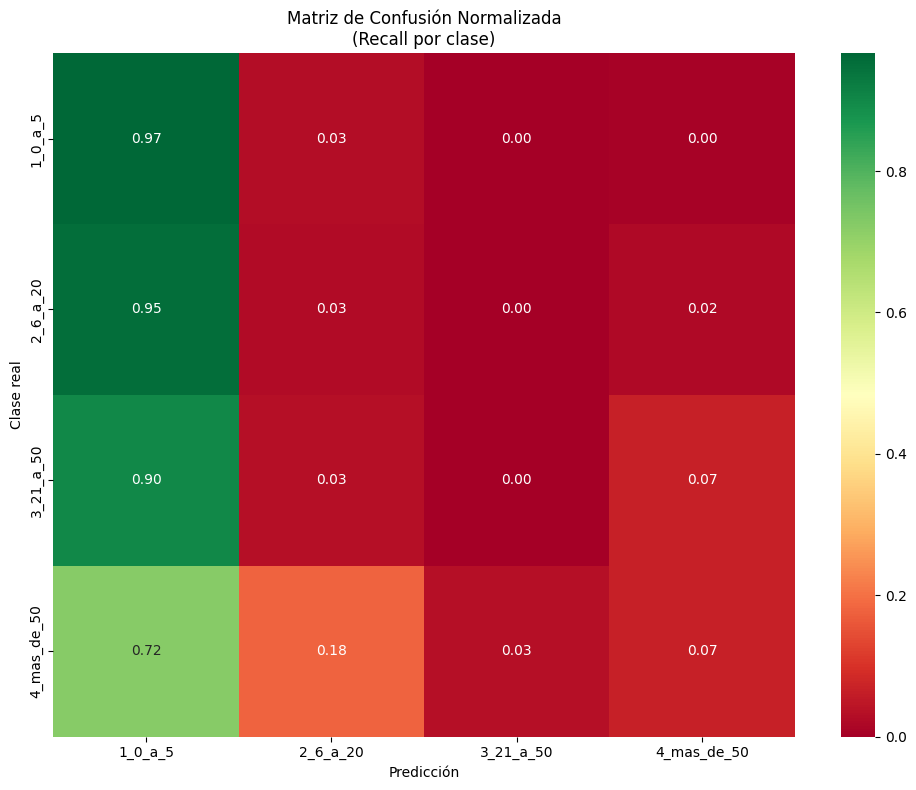

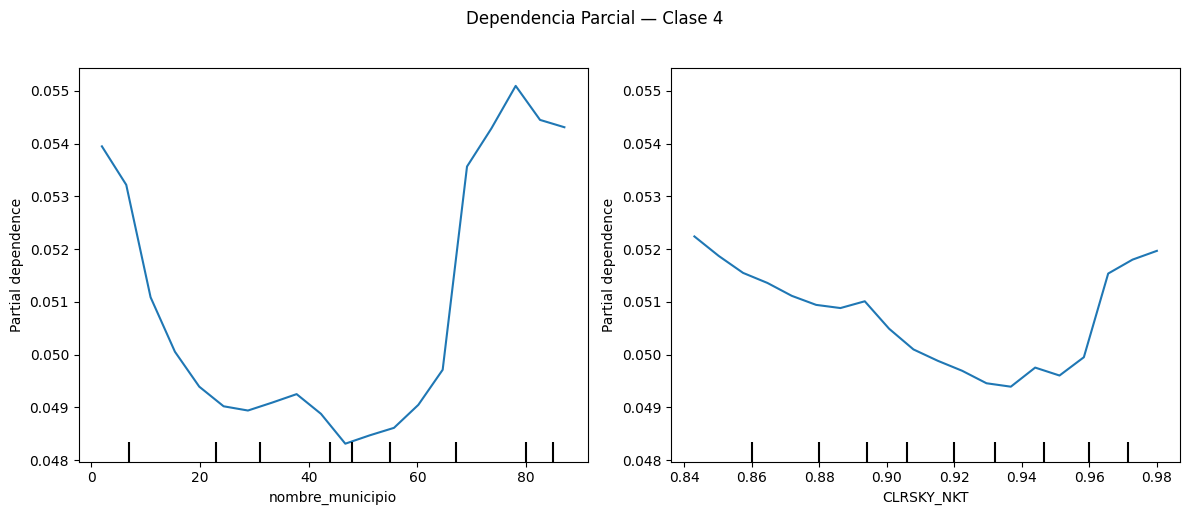

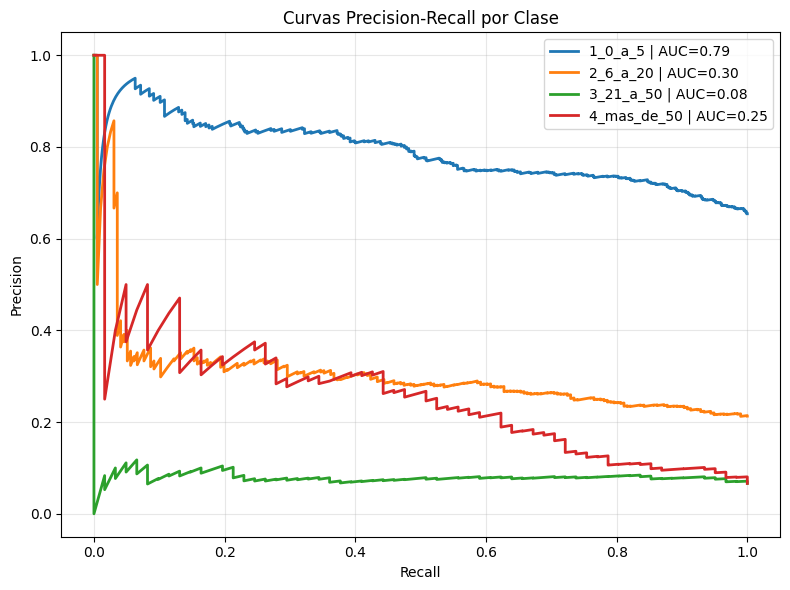

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import learning_curve
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import auc
from sklearn.inspection import PartialDependenceDisplay


# ============================================================
# 1) CURVA DE APRENDIZAJE
# ============================================================
def plot_learning_curve(clf, X_train, y_train):

    # respetar temporalidad
    tscv = TimeSeriesSplit(n_splits=3)

    train_sizes, train_scores, val_scores = learning_curve(
        estimator=clf,
        X=X_train,
        y=y_train,
        cv=tscv,
        n_jobs=-1,
        train_sizes=np.linspace(0.2, 1.0, 5),
        scoring='f1_macro'
    )

    train_mean = train_scores.mean(axis=1)
    val_mean   = val_scores.mean(axis=1)

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.plot(
        train_sizes,
        train_mean,
        marker='o',
        linewidth=2,
        label='Entrenamiento'
    )

    ax.plot(
        train_sizes,
        val_mean,
        marker='o',
        linewidth=2,
        label='Validación interna'
    )

    ax.set_title('Curvas de Aprendizaje (F1 Macro)')
    ax.set_xlabel('Tamaño del dataset de entrenamiento')
    ax.set_ylabel('F1 Macro')
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()


# ============================================================
# 2) MATRIZ NORMALIZADA
# ============================================================
def plot_normalized_cm(clf, X_val, y_val):

    y_pred = clf.predict(X_val)

    cm = confusion_matrix(
        y_val,
        y_pred,
        labels=clf.classes_
    )

    # normalizar por fila
    row_sum = cm.sum(axis=1, keepdims=True)
    row_sum[row_sum == 0] = 1

    cm_norm = cm / row_sum

    fig, ax = plt.subplots(figsize=(10, 8))

    sns.heatmap(
        cm_norm,
        annot=True,
        fmt='.2f',
        cmap='RdYlGn',
        xticklabels=clf.classes_,
        yticklabels=clf.classes_,
        ax=ax
    )

    ax.set_title(
        'Matriz de Confusión Normalizada\n(Recall por clase)'
    )
    ax.set_ylabel('Clase real')
    ax.set_xlabel('Predicción')

    plt.tight_layout()
    plt.show()


# ============================================================
# 3) PDP
# ============================================================
def plot_pdp(clf, X_train, features_to_plot):

    features_validas = [
        c for c in features_to_plot
        if c in X_train.columns
    ]

    if len(features_validas) == 0:
        print("No hay variables válidas para PDP.")
        return

    fig, ax = plt.subplots(
        figsize=(12, 5),
        ncols=len(features_validas)
    )

    PartialDependenceDisplay.from_estimator(
        estimator=clf,
        X=X_train,
        features=features_validas,
        target='4_mas_de_50',
        grid_resolution=20,
        ax=ax
    )

    plt.suptitle(
        'Dependencia Parcial — Clase 4',
        y=1.02
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 4) PRECISION-RECALL
# ============================================================
def plot_multiclass_precision_recall(clf, X_val, y_val):

    y_score = clf.predict_proba(X_val)

    fig, ax = plt.subplots(figsize=(8, 6))

    for i, clase in enumerate(clf.classes_):

        y_true_bin = (y_val == clase).astype(int)

        precision, recall, _ = precision_recall_curve(
            y_true_bin,
            y_score[:, i]
        )

        pr_auc = auc(recall, precision)

        ax.plot(
            recall,
            precision,
            linewidth=2,
            label=f'{clase} | AUC={pr_auc:.2f}'
        )

    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title('Curvas Precision-Recall por Clase')
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()


# ============================================================
# EJECUCIÓN
# ============================================================

# 1) Curva aprendizaje
plot_learning_curve(clf, X_train, y_train)

# 2) Matriz normalizada (2023)
plot_normalized_cm(clf, X_val, y_val)

# 3) PDP
plot_pdp(
    clf,
    X_train,
    ['nombre_municipio', 'CLRSKY_NKT']
)

# 4) Precision-Recall
plot_multiclass_precision_recall(
    clf,
    X_val,
    y_val
)

# Experimento 2

In [21]:
import sys, os, duckdb
import pandas as pd

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from config.config import V2_DB

con = duckdb.connect(V2_DB)

# ==============================================================================
# 0. VARIABLES DESCARTADAS (El filtro de entrada)
# ==============================================================================
VARS_DESCARTADAS = (
    'CLOUD_BT', 'CLOUD_BT_MAX', 'CLOUD_BT_MIN',
    'CLOUD_TT', 'CLOUD_TT_MAX', 'CLOUD_TT_MIN',
    'GWM_HEIGHT', 'GWM_HEIGHT_ANOMALY',
    'IMERG_PRECLIQUID_PROB', 'IMERG_PRECTOT', 'IMERG_PRECTOT_COUNT',
    'LWLAND', 'ORIGINAL_ALLSKY_SFC_LW_DWN', 'ORIGINAL_ALLSKY_SFC_SW_DWN',
    'ORIGINAL_CLRSKY_SFC_LW_DWN', 'ORIGINAL_CLRSKY_SFC_SW_DWN',
    'PRMC', 'PRMC_PRCNTL', 'RZMC', 'RZMC_PRCNTL',
    'SFMC', 'SWLAND', 'SZA'
)
vars_excluidas_sql = ", ".join([f"'{v}'" for v in VARS_DESCARTADAS])

# ==============================================================================
# 1. CARGA Y CLASIFICACIÓN INTELIGENTE (Solo variables válidas)
# ==============================================================================
# Filtramos el diccionario desde el inicio
df_diccionario = con.execute(f"""
    SELECT id_variable, fuente, nombre_completo 
    FROM working.diccionario 
    WHERE id_variable NOT IN ({vars_excluidas_sql})
""").df()

pivot_statements = []

for _, row in df_diccionario.iterrows():
    vid = row['id_variable']
    fuente = str(row['fuente']).lower()
    nombre = str(row['nombre_completo']).lower()
    
    base_case = f"CASE WHEN id_variable = '{vid}' THEN resultado_numerico END"
    
    if 'google' in fuente:
        pivot_statements.append(f"MAX({base_case}) AS \"{vid}\"")
    elif any(k in nombre for k in ['precipitation', 'precip', 'snow', 'rain']):
        pivot_statements.append(f"SUM({base_case}) AS \"{vid}_SUM\"")
    elif any(k in nombre for k in ['humidity', 'wetness', 'moisture']):
        pivot_statements.append(f"MIN({base_case}) AS \"{vid}_MIN\"")
    elif any(k in nombre for k in ['wind', 'speed']):
        pivot_statements.append(f"MAX({base_case}) AS \"{vid}_MAX\"")
        pivot_statements.append(f"STDDEV({base_case}) AS \"{vid}_STD\"")
    elif any(k in nombre for k in ['temperature', 'irradiance', 'insolation', 'solar', 'thermal', 'albedo', 'par', 'cdd']):
        pivot_statements.append(f"MAX({base_case}) AS \"{vid}_MAX\"")
    else:
        pivot_statements.append(f"MEDIAN({base_case}) AS \"{vid}_MEDIAN\"")

pivot_cols = ",\n    ".join(pivot_statements)

# ==============================================================================
# 2. EXTRACCIÓN CON DUCKDB (Filtrando variables descartadas para optimizar RAM)
# ==============================================================================
df = con.execute(f"""
    WITH clima_pivot AS (
        SELECT
            id_clave_inc,
            {pivot_cols}
        FROM working.climatologia
        WHERE id_variable NOT IN ({vars_excluidas_sql})
        GROUP BY id_clave_inc
    ),
    demo_total AS (
        SELECT
            id_cvegeo,
            anio,
            SUM(pob_total) AS pob_total
        FROM working.demografia
        GROUP BY id_cvegeo, anio
    )
    SELECT
        i.id_clave_inc,
        i.latitud,
        i.longitud,
        i.anio,
        EXTRACT(MONTH FROM i.fecha_inicio)::INTEGER AS mes,
        EXTRACT(DOW   FROM i.fecha_inicio)::INTEGER AS dia_semana,
        i.tipo_de_incendio,
        v.tipo_de_vegetacion,
        v.regimen_del_fuego,
        o.hora_deteccion,
        dem.pob_total,
        d.tamanio,
        cp.*
    FROM working.incendios i
    LEFT JOIN working.vegetacion   v   ON i.id_vegetacion = v.id_vegetacion
    LEFT JOIN working.municipios   m   ON i.id_cvegeo     = m.id_cvegeo
    LEFT JOIN working.operaciones  o   ON i.id_clave_inc  = o.id_clave_inc
    LEFT JOIN working.danos        d   ON i.id_clave_inc  = d.id_clave_inc
    LEFT JOIN demo_total           dem ON i.id_cvegeo     = dem.id_cvegeo
                                      AND i.anio          = dem.anio
    LEFT JOIN clima_pivot          cp  ON i.id_clave_inc  = cp.id_clave_inc
""").df()

con.close()

# ==============================================================================
# 3. LIMPIEZA INICIAL
# ==============================================================================
df = df.loc[:, ~df.columns.duplicated()]

df['hora_deteccion'] = pd.to_datetime(df['hora_deteccion'].astype(str), errors='coerce')
df['hora_deteccion_min'] = (df['hora_deteccion'].dt.hour * 60 + df['hora_deteccion'].dt.minute)
df = df.drop(columns=['hora_deteccion'])

print(f"Dimensiones tras extracción: {df.shape}")

# ==============================================================================
# 4. LIMPIEZA QUIRÚRGICA, UNIFICACIÓN Y NULOS
# ==============================================================================
# Eliminar filas sin coordenadas
df_clean = df.dropna(subset=['latitud', 'longitud']).copy()

# Mapeo del Target
mapeo_clases = {
    '0 a 5 hectareas':       '1_0_a_5',
    '6 a 10 hectareas':      '2_6_a_20',
    '11 a 20 hectareas':     '2_6_a_20',
    '21 a 50 hectareas':     '3_21_a_50',
    '51 a 100 hectareas':    '4_mas_de_50',
    'mayor a 100 hectareas': '4_mas_de_50'
}
df_clean['tamanio_modelo'] = df_clean['tamanio'].map(mapeo_clases)

# Eliminar columnas 100% nulas (Fantasmas generadas por variables sin datos)
df_clean = df_clean.dropna(axis=1, how='all')

# Imputar nulos restantes (Suelos antiguos, NDMI) con la mediana
cols_numericas = df_clean.select_dtypes(include=['float64', 'float32', 'int64', 'int32']).columns
df_clean[cols_numericas] = df_clean[cols_numericas].fillna(df_clean[cols_numericas].median())

# Seguridad contra nulos persistentes
df_clean[cols_numericas] = df_clean[cols_numericas].fillna(0)

print(f"Dimensiones finales (listas para el modelo): {df_clean.shape}")
print(f"Total de valores nulos: {df_clean.isnull().sum().sum()}")
print("\n--- Distribución Final del Target ---")
print(df_clean['tamanio_modelo'].value_counts(dropna=False))

Dimensiones tras extracción: (12703, 157)
Dimensiones finales (listas para el modelo): (12529, 157)
Total de valores nulos: 0

--- Distribución Final del Target ---
tamanio_modelo
1_0_a_5        9536
2_6_a_20       2008
3_21_a_50       543
4_mas_de_50     442
Name: count, dtype: int64


C:\Users\jrf24\AppData\Local\Temp\ipykernel_15480\3314694513.py:112: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['hora_deteccion'] = pd.to_datetime(df['hora_deteccion'].astype(str), errors='coerce')


C:\Users\jrf24\AppData\Local\Temp\ipykernel_15480\3642937954.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='tamanio_modelo', y=var_calor, data=df_clean,
C:\Users\jrf24\AppData\Local\Temp\ipykernel_15480\3642937954.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='tamanio_modelo', y=var_humedad, data=df_clean,
C:\Users\jrf24\AppData\Local\Temp\ipykernel_15480\3642937954.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='tamanio_modelo', y=var_viento, data=df_clean,


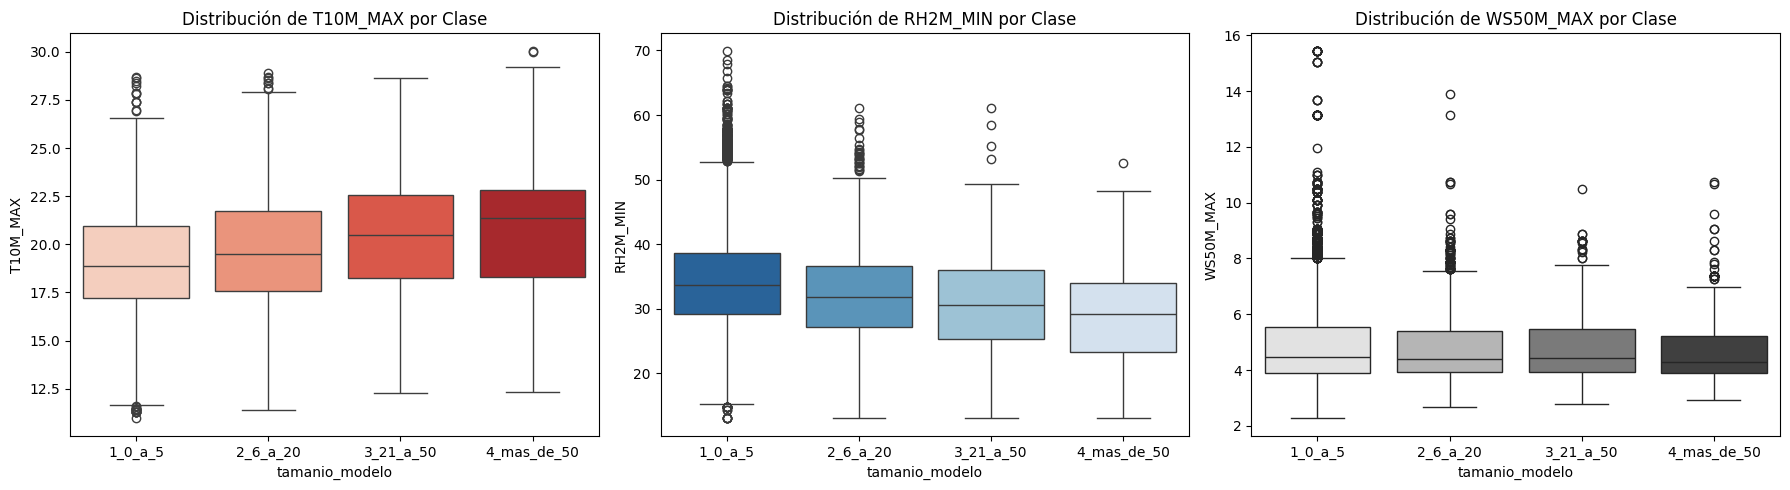

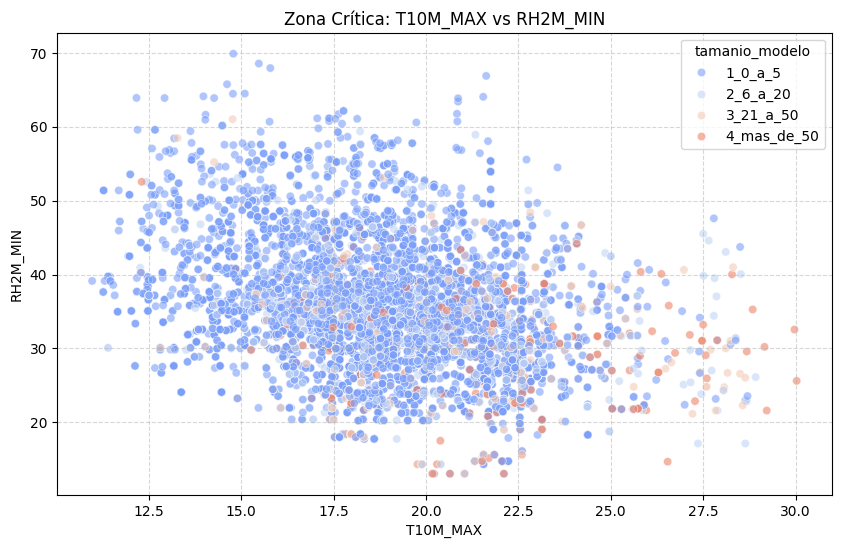

Text(0.5, 1.0, 'Matriz de Correlación - Nuevas Variables Pico')

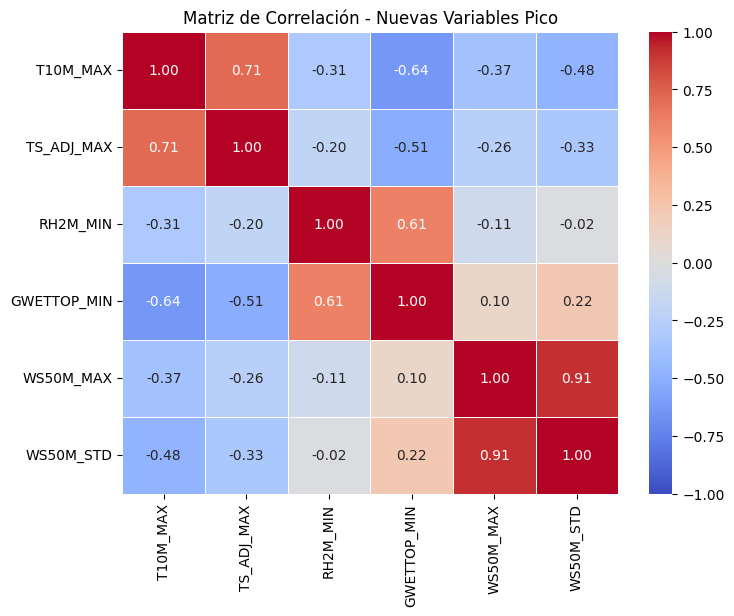

In [22]:

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ==============================================================================
# 1. VISUALIZACIÓN DE SEPARACIÓN DE CLASES (Boxplots y Scatter)
# ==============================================================================
# Nota: Ajusta los nombres de las columnas si en tu DF se llaman ligeramente distinto.
# Usaremos variables representativas que sabemos que salieron del diccionario.

# Elegimos 3 variables críticas de los nuevos grupos
var_calor = 'T10M_MAX'    # El pico de temperatura
var_humedad = 'RH2M_MIN'  # La caída crítica de humedad
var_viento = 'WS50M_MAX'  # Las ráfagas máximas

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1A. Boxplots: ¿Los incendios Clase 4 tienen picos más altos?
sns.boxplot(x='tamanio_modelo', y=var_calor, data=df_clean, 
            order=['1_0_a_5', '2_6_a_20', '3_21_a_50', '4_mas_de_50'], ax=axes[0], palette='Reds')
axes[0].set_title(f'Distribución de {var_calor} por Clase')

sns.boxplot(x='tamanio_modelo', y=var_humedad, data=df_clean, 
            order=['1_0_a_5', '2_6_a_20', '3_21_a_50', '4_mas_de_50'], ax=axes[1], palette='Blues_r')
axes[1].set_title(f'Distribución de {var_humedad} por Clase')

sns.boxplot(x='tamanio_modelo', y=var_viento, data=df_clean, 
            order=['1_0_a_5', '2_6_a_20', '3_21_a_50', '4_mas_de_50'], ax=axes[2], palette='Greys')
axes[2].set_title(f'Distribución de {var_viento} por Clase')

plt.tight_layout()
plt.show()

# 1B. Scatterplot 2D: Buscando la "Zona de Peligro"
plt.figure(figsize=(10, 6))
sns.scatterplot(x=var_calor, y=var_humedad, hue='tamanio_modelo', 
                hue_order=['1_0_a_5', '2_6_a_20', '3_21_a_50', '4_mas_de_50'],
                data=df_clean, alpha=0.6, palette='coolwarm')
plt.title(f'Zona Crítica: {var_calor} vs {var_humedad}')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# ==============================================================================
# 2. VERIFICACIÓN DE MULTICOLINEALIDAD (Matriz de Correlación)
# ==============================================================================
# Evaluar si las métricas derivadas de una misma fuente (o fuentes similares) 
# están diciendo exactamente lo mismo (correlación > 0.90)

# Seleccionamos un grupo de variables nuevas para inspeccionar
cols_a_revisar = [
    'T10M_MAX', 'TS_ADJ_MAX', # Dos medidas de calor
    'RH2M_MIN', 'GWETTOP_MIN', # Dos medidas de sequedad
    'WS50M_MAX', 'WS50M_STD'  # Viento: Ráfaga vs Inestabilidad
]

# Filtrar solo las que realmente existan en el DataFrame para evitar errores
cols_existentes = [c for c in cols_a_revisar if c in df_clean.columns]

plt.figure(figsize=(8, 6))
corr_matrix = df_clean[cols_existentes].corr()

# Mapa de calor
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación - Nuevas Variables Pico')



In [23]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

TARGET_COL = "tamanio_modelo"

cols_a_excluir = [
    "id_clave_inc",
    "tamanio",
    TARGET_COL
]

if "id_clave_inc_1" in df_clean.columns:
    cols_a_excluir.append("id_clave_inc_1")

# =========================================================
# 1) SPLIT TEMPORAL
# =========================================================
train = df_clean[df_clean["anio"] <= 2022].copy()
val   = df_clean[df_clean["anio"] == 2023].copy()
test  = df_clean[df_clean["anio"] >= 2024].copy()

# =========================================================
# 2) X / y
# =========================================================
X_train = train.drop(columns=cols_a_excluir)
y_train = train[TARGET_COL]

X_val = val.drop(columns=cols_a_excluir)
y_val = val[TARGET_COL]

X_test = test.drop(columns=cols_a_excluir)
y_test = test[TARGET_COL]

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

# =========================================================
# 3) ENCODING
# =========================================================
cols_categoricas = [
    "tipo_de_incendio",
    "tipo_de_vegetacion",
    "regimen_del_fuego"
]

enc = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

X_train[cols_categoricas] = enc.fit_transform(
    X_train[cols_categoricas]
)

X_val[cols_categoricas] = enc.transform(
    X_val[cols_categoricas]
)

X_test[cols_categoricas] = enc.transform(
    X_test[cols_categoricas]
)

# =========================================================
# 4) MODELO
# =========================================================
clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=15,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

clf.fit(X_train, y_train)

# =========================================================
# 5) VALIDACIÓN
# =========================================================
y_pred_val = clf.predict(X_val)

print(classification_report(y_val, y_pred_val))

# =========================================================
# 6) TEST FINAL
# =========================================================
y_pred_test = clf.predict(X_test)

print("\nTEST:")
print(classification_report(y_test, y_pred_test))

(9743, 153)
(920, 153)
(1866, 153)
              precision    recall  f1-score   support

     1_0_a_5       0.72      0.77      0.74       602
    2_6_a_20       0.26      0.31      0.28       196
   3_21_a_50       0.06      0.02      0.03        61
 4_mas_de_50       0.30      0.10      0.15        61

    accuracy                           0.58       920
   macro avg       0.33      0.30      0.30       920
weighted avg       0.55      0.58      0.56       920


TEST:
              precision    recall  f1-score   support

     1_0_a_5       0.63      0.72      0.67      1037
    2_6_a_20       0.22      0.20      0.21       445
   3_21_a_50       0.15      0.09      0.11       190
 4_mas_de_50       0.18      0.15      0.16       194

    accuracy                           0.47      1866
   macro avg       0.30      0.29      0.29      1866
weighted avg       0.44      0.47      0.45      1866




--- REPORTE VALIDACIÓN ---
              precision    recall  f1-score   support

     1_0_a_5       0.72      0.77      0.74       602
    2_6_a_20       0.26      0.31      0.28       196
   3_21_a_50       0.06      0.02      0.03        61
 4_mas_de_50       0.30      0.10      0.15        61

    accuracy                           0.58       920
   macro avg       0.33      0.30      0.30       920
weighted avg       0.55      0.58      0.56       920



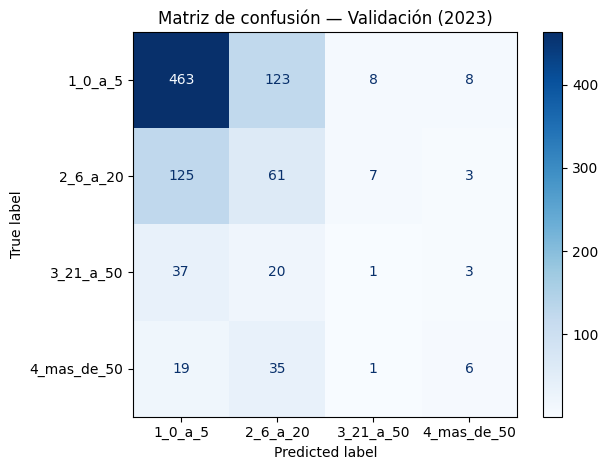


--- REPORTE TEST ---
              precision    recall  f1-score   support

     1_0_a_5       0.63      0.72      0.67      1037
    2_6_a_20       0.22      0.20      0.21       445
   3_21_a_50       0.15      0.09      0.11       190
 4_mas_de_50       0.18      0.15      0.16       194

    accuracy                           0.47      1866
   macro avg       0.30      0.29      0.29      1866
weighted avg       0.44      0.47      0.45      1866



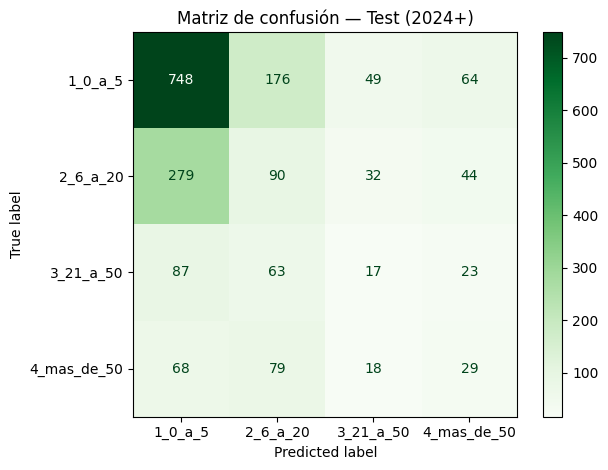

In [24]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# =========================================================
# VALIDACIÓN
# =========================================================
y_pred_val = clf.predict(X_val)

print("\n--- REPORTE VALIDACIÓN ---")
print(classification_report(y_val, y_pred_val))

cm_val = confusion_matrix(
    y_val,
    y_pred_val,
    labels=clf.classes_
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_val,
    display_labels=clf.classes_
)

disp.plot(cmap="Blues")
plt.title("Matriz de confusión — Validación (2023)")
plt.tight_layout()
plt.show()


# =========================================================
# TEST FINAL
# =========================================================
y_pred_test = clf.predict(X_test)

print("\n--- REPORTE TEST ---")
print(classification_report(y_test, y_pred_test))

cm_test = confusion_matrix(
    y_test,
    y_pred_test,
    labels=clf.classes_
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=clf.classes_
)

disp.plot(cmap="Greens")
plt.title("Matriz de confusión — Test (2024+)")
plt.tight_layout()
plt.show()


--- TOP 25 VARIABLES MÁS IMPORTANTES ---
        Variable  Importancia
        longitud     0.021437
         latitud     0.020256
       pob_total     0.018568
      TSOIL6_MAX     0.014869
  EVPTRNS_MEDIAN     0.014130
            anio     0.014121
            NDWI     0.013200
          PW_SUM     0.011858
      TSOIL5_MAX     0.011602
            NDMI     0.011460
            NDVI     0.011454
       PS_MEDIAN     0.010119
   EVLAND_MEDIAN     0.009915
      TO3_MEDIAN     0.009746
     T2M_MAX_MAX     0.009714
        RH2M_MIN     0.009621
 CLOUD_OD_MEDIAN     0.009582
      TSOIL4_MAX     0.009391
MIDDAY_INSOL_MAX     0.009352
  WS2M_RANGE_STD     0.009113
         V2M_STD     0.009080
 WS50M_RANGE_STD     0.009061
    WS2M_MAX_STD     0.008945
   PBLTOP_MEDIAN     0.008874
   AOD_55_MEDIAN     0.008788


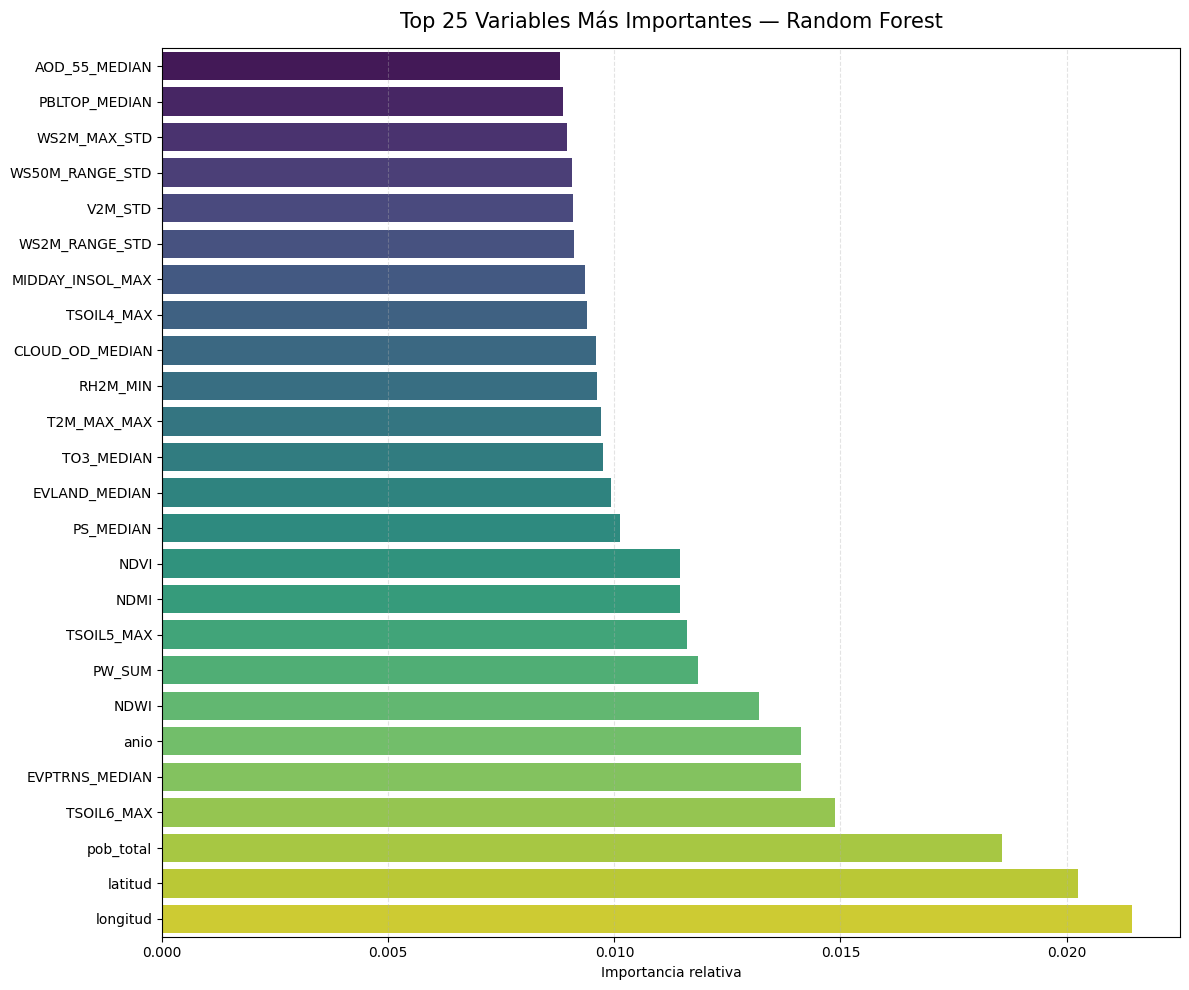

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ================================================================
# FEATURE IMPORTANCE — RANDOM FOREST
# ================================================================

# 1) Extraer importancias
importancias = clf.feature_importances_

# 2) Nombres de variables
nombres_features = X_train.columns.tolist()

# 3) DataFrame ordenado
df_importancias = (
    pd.DataFrame({
        "Variable": nombres_features,
        "Importancia": importancias
    })
    .sort_values("Importancia", ascending=False)
    .reset_index(drop=True)
)

# 4) Mostrar top 25
print("\n--- TOP 25 VARIABLES MÁS IMPORTANTES ---")
print(df_importancias.head(25).to_string(index=False))

# ================================================================
# GRÁFICA
# ================================================================
top_n = 25
df_top = df_importancias.head(top_n).iloc[::-1]  # invertir para mejor lectura

fig, ax = plt.subplots(figsize=(12, 10))

sns.barplot(
    data=df_top,
    x="Importancia",
    y="Variable",
    hue="Variable",      # evita warning de seaborn
    palette="viridis",
    dodge=False,
    legend=False,
    ax=ax
)

ax.set_title(
    "Top 25 Variables Más Importantes — Random Forest",
    fontsize=15,
    pad=15
)

ax.set_xlabel("Importancia relativa")
ax.set_ylabel("")
ax.grid(axis="x", linestyle="--", alpha=0.35)

plt.tight_layout()
plt.show()

1/5 Calculando Curva de Aprendizaje...


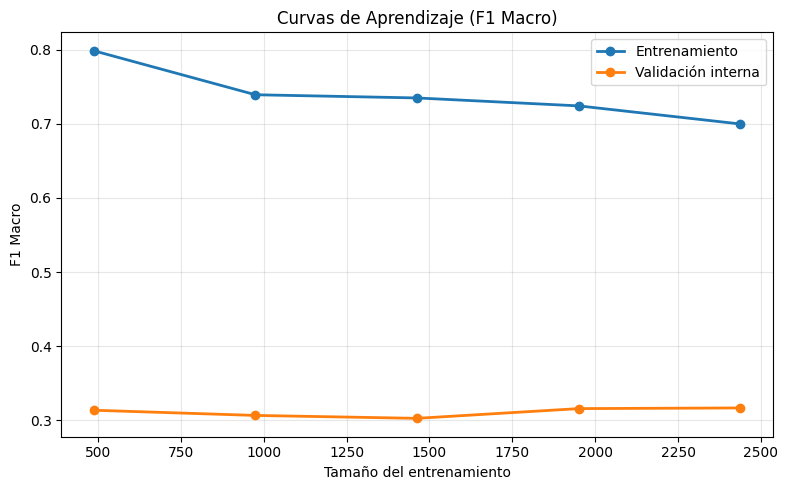

2/5 Generando Matriz de Confusión...


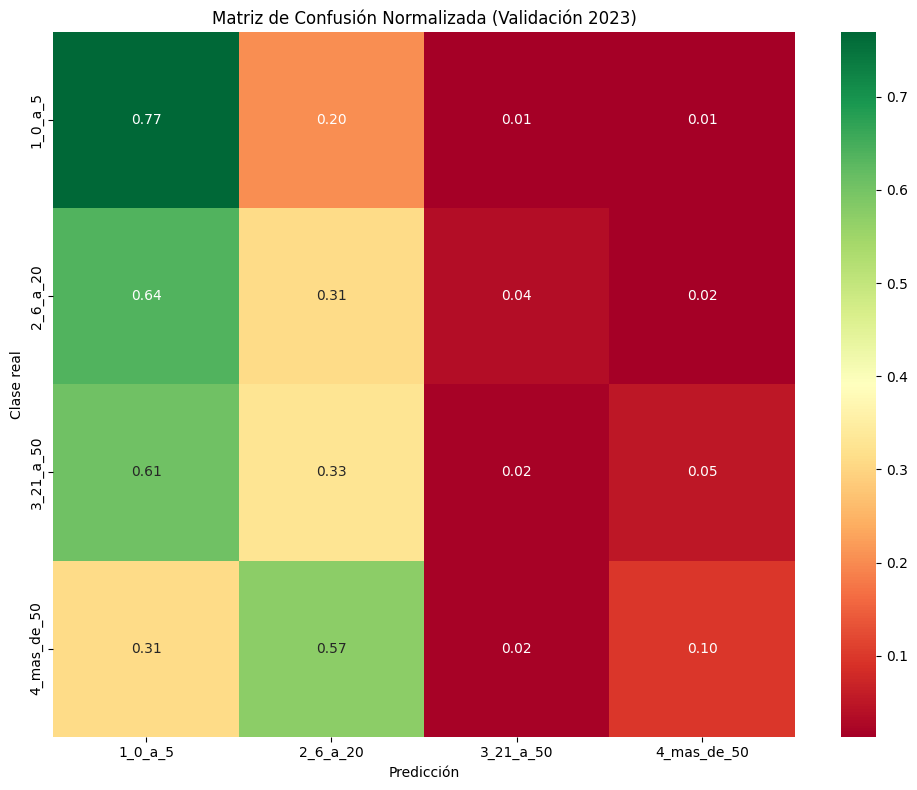

3/5 Analizando importancia de variables...


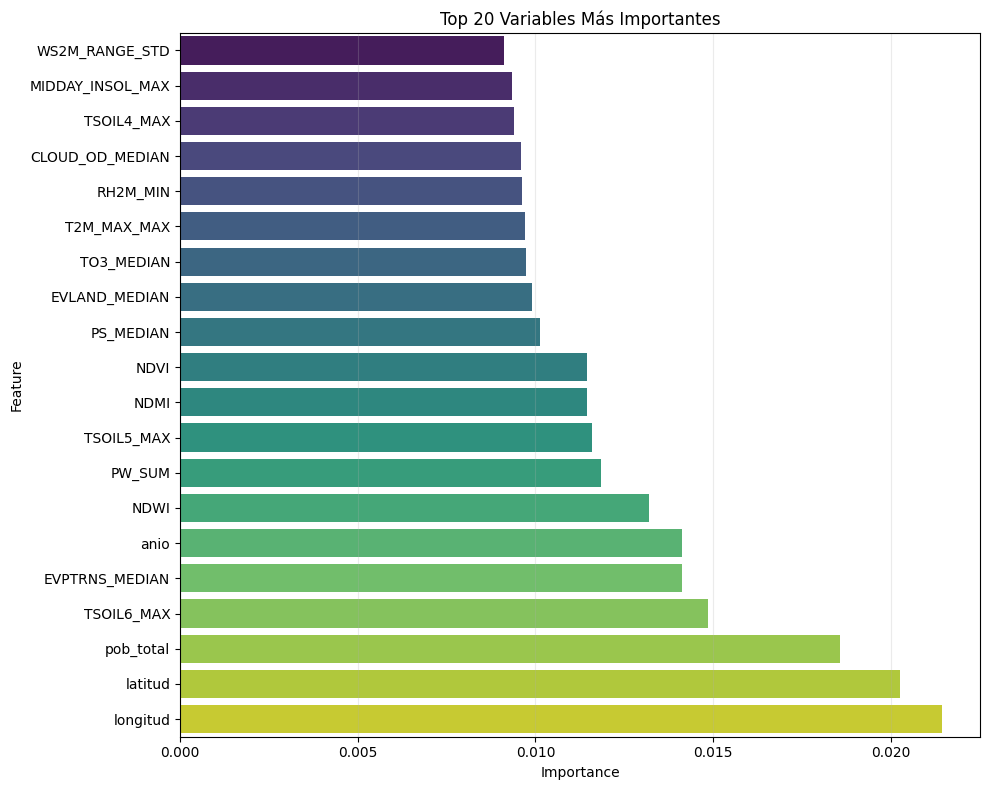

4/5 Calculando PDP...


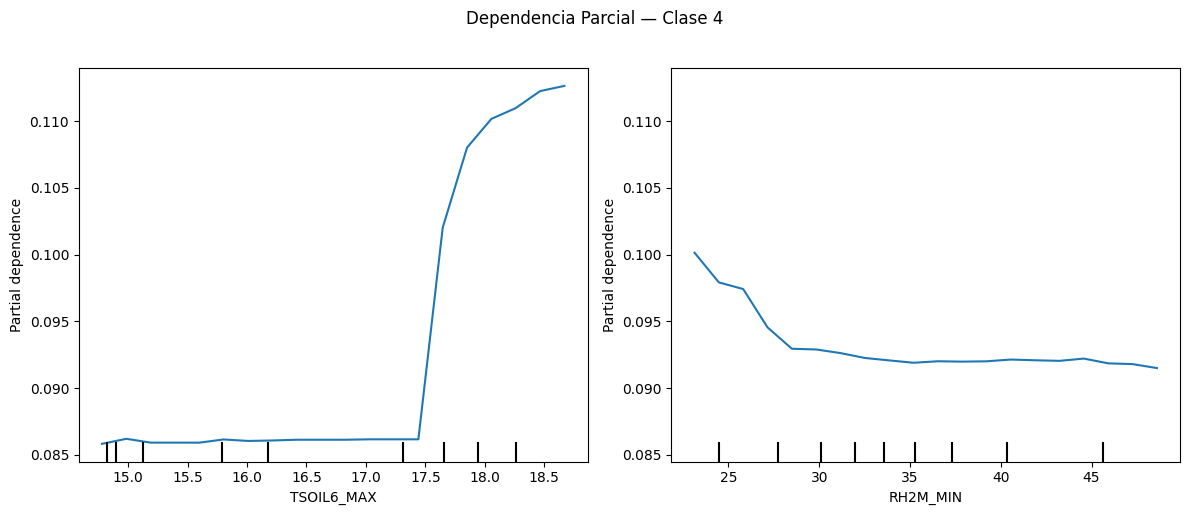

5/5 Analizando falsos negativos...

--- REPORTE ---
Clase 4 clasificados como clase 1: 19

Promedio Validación:
TSOIL6_MAX        16.791272
RH2M_MIN          35.663119
pob_total     168271.235870
dtype: float64

Promedio Falsos Negativos:
TSOIL6_MAX        16.499474
RH2M_MIN          36.015789
pob_total     238644.157895
dtype: float64
6/6 Curvas Precision-Recall...


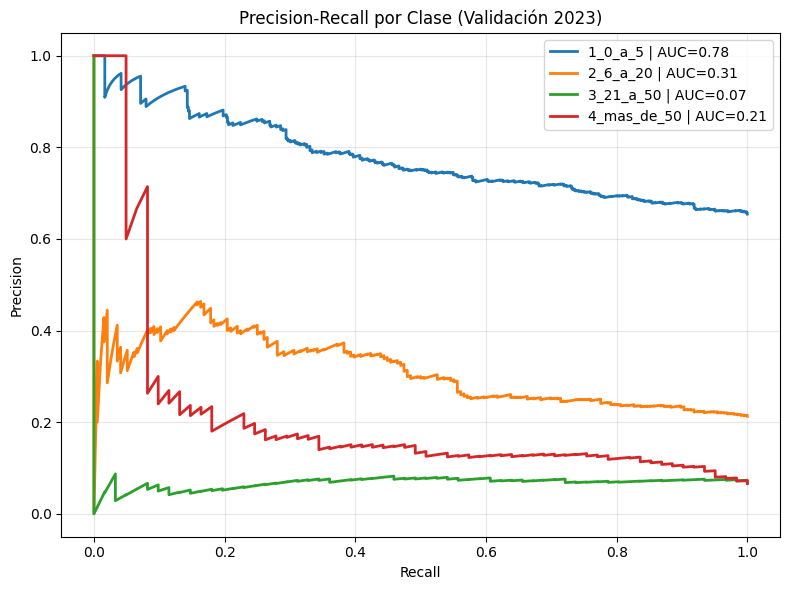

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import learning_curve
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import auc
from sklearn.inspection import PartialDependenceDisplay


# ============================================================
# PARCHE DE SEGURIDAD PARA EVITAR LOSSYSETITEMERROR EN WINDOWS
# ============================================================
# Convertimos todas las columnas numéricas de precisión simple a precisión doble
X_train = X_train.astype({col: 'float64' for col in X_train.select_dtypes(include=['float32']).columns})
X_val = X_val.astype({col: 'float64' for col in X_val.select_dtypes(include=['float32']).columns})


# ============================================================
# PREDICCIÓN SOBRE VALIDACIÓN (2023)
# ============================================================
y_pred_val = clf.predict(X_val)


# ============================================================
# 1) CURVA DE APRENDIZAJE
# ============================================================
print("1/5 Calculando Curva de Aprendizaje...")

tscv = TimeSeriesSplit(n_splits=3)

train_sizes, train_scores, val_scores = learning_curve(
    estimator=clf,
    X=X_train,
    y=y_train,
    cv=tscv,
    n_jobs=-1,
    scoring="f1_macro",
    train_sizes=np.linspace(0.2, 1.0, 5)
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    train_sizes,
    train_scores.mean(axis=1),
    marker="o",
    linewidth=2,
    label="Entrenamiento"
)

ax.plot(
    train_sizes,
    val_scores.mean(axis=1),
    marker="o",
    linewidth=2,
    label="Validación interna"
)

ax.set_title("Curvas de Aprendizaje (F1 Macro)")
ax.set_xlabel("Tamaño del entrenamiento")
ax.set_ylabel("F1 Macro")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 2) MATRIZ NORMALIZADA
# ============================================================
print("2/5 Generando Matriz de Confusión...")

cm = confusion_matrix(
    y_val,
    y_pred_val,
    labels=clf.classes_
)

row_sum = cm.sum(axis=1, keepdims=True)
row_sum[row_sum == 0] = 1
cm_norm = cm / row_sum

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    xticklabels=clf.classes_,
    yticklabels=clf.classes_,
    ax=ax
)

ax.set_title(
    "Matriz de Confusión Normalizada (Validación 2023)"
)
ax.set_ylabel("Clase real")
ax.set_xlabel("Predicción")

plt.tight_layout()
plt.show()


# ============================================================
# 3) FEATURE IMPORTANCE
# ============================================================
print("3/5 Analizando importancia de variables...")

df_importancias = (
    pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": clf.feature_importances_
    })
    .sort_values("Importance", ascending=False)
)

top20 = df_importancias.head(20).iloc[::-1]

fig, ax = plt.subplots(figsize=(10, 8))

sns.barplot(
    data=top20,
    x="Importance",
    y="Feature",
    hue="Feature",
    dodge=False,
    legend=False,
    palette="viridis",
    ax=ax
)

ax.set_title("Top 20 Variables Más Importantes")
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()


# ============================================================
# 4) PDP
# ============================================================
print("4/5 Calculando PDP...")

features_to_plot = [
    c for c in ["TSOIL6_MAX", "RH2M_MIN"]
    if c in X_train.columns
]

if len(features_to_plot):

    fig, ax = plt.subplots(
        figsize=(12, 5),
        ncols=len(features_to_plot)
    )

    PartialDependenceDisplay.from_estimator(
        estimator=clf,
        X=X_train,
        features=features_to_plot,
        target="4_mas_de_50",
        grid_resolution=20,
        ax=ax
    )

    plt.suptitle(
        "Dependencia Parcial — Clase 4",
        y=1.02
    )

    plt.tight_layout()
    plt.show()

else:
    print("Variables PDP no encontradas.")


# ============================================================
# 5) AUTOPSIA DE FALSOS NEGATIVOS
# ============================================================
print("5/5 Analizando falsos negativos...")

df_val_analysis = X_val.copy()
df_val_analysis["Real"] = y_val.values
df_val_analysis["Pred"] = y_pred_val

falsos_negativos = df_val_analysis[
    (df_val_analysis["Real"] == "4_mas_de_50") &
    (df_val_analysis["Pred"] == "1_0_a_5")
]

print("\n--- REPORTE ---")
print(
    f"Clase 4 clasificados como clase 1: "
    f"{len(falsos_negativos)}"
)

variables_criticas = [
    c for c in ["TSOIL6_MAX", "RH2M_MIN", "pob_total"]
    if c in X_val.columns
]

if variables_criticas:

    print("\nPromedio Validación:")
    print(X_val[variables_criticas].mean())

    print("\nPromedio Falsos Negativos:")

    if not falsos_negativos.empty:
        print(
            falsos_negativos[variables_criticas].mean()
        )
    else:
        print("No hubo falsos negativos críticos.")


# ============================================================
# 6) PRECISION-RECALL
# ============================================================
print("6/6 Curvas Precision-Recall...")

y_score = clf.predict_proba(X_val)

fig, ax = plt.subplots(figsize=(8, 6))

for i, clase in enumerate(clf.classes_):

    y_true_bin = (y_val == clase).astype(int)

    precision, recall, _ = precision_recall_curve(
        y_true_bin,
        y_score[:, i]
    )

    pr_auc = auc(recall, precision)

    ax.plot(
        recall,
        precision,
        linewidth=2,
        label=f"{clase} | AUC={pr_auc:.2f}"
    )

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall por Clase (Validación 2023)")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [27]:
# ¿Ha cambiado la proporción de incendios grandes con el tiempo?
print(df_clean.groupby('anio')['tamanio_modelo'].value_counts(normalize=True).unstack())

tamanio_modelo   1_0_a_5  2_6_a_20  3_21_a_50  4_mas_de_50
anio                                                      
2015            0.908333  0.085417   0.006250          NaN
2016            0.883820  0.102637   0.012117     0.001426
2017            0.843273  0.121359   0.020111     0.015257
2018            0.840146  0.116058   0.032117     0.011679
2019            0.816825  0.137042   0.029172     0.016961
2020            0.758748  0.183241   0.032228     0.025783
2021            0.758389  0.165772   0.041611     0.034228
2022            0.697395  0.200401   0.059118     0.043086
2023            0.654348  0.213043   0.066304     0.066304
2024            0.561567  0.221082   0.100746     0.116604
2025            0.547859  0.261965   0.103275     0.086902


# Experimento 3 


### Random Forest con Selección de Características y Balanceo de Clases

**Objetivo:** Mitigar el problema del desbalanceo extremo detectado en el Experimento 2 mediante estrategias de balanceo y reducir la redundancia eliminando variables climáticas altamente correlacionadas.

In [28]:
print(df.columns.tolist())

['id_clave_inc', 'latitud', 'longitud', 'anio', 'mes', 'dia_semana', 'tipo_de_incendio', 'tipo_de_vegetacion', 'regimen_del_fuego', 'pob_total', 'tamanio', 'id_clave_inc_1', 'WS50M_MAX', 'WS50M_STD', 'ALLSKY_SFC_LW_DWN_MAX', 'ALLSKY_SFC_SW_DNI_MAX', 'GWETTOP_MIN', 'WS10M_MAX_MAX', 'WS10M_MAX_STD', 'WS10M_MIN_MAX', 'WS10M_MIN_STD', 'AOD_84_MEDIAN', 'CLRSKY_SFC_LW_DWN_MAX', 'PRECSNO_SUM', 'QV10M_MIN', 'T10M_MAX', 'T10M_RANGE_MAX', 'TROPQ_MIN', 'TS_ADJ_MAX', 'TS_RANGE_MAX', 'V50M_MAX', 'V50M_STD', 'Z0M_MEDIAN', 'PRECTOTCORR_SUM', 'ALLSKY_KT_MAX', 'GWETROOT_MIN', 'AOD_55_MEDIAN', 'AIRMASS_MEDIAN', 'ALLSKY_SFC_PAR_DIFF_MAX', 'ALLSKY_SFC_PAR_DIRH_MAX', 'ALLSKY_SFC_SW_DIRH_MAX', 'AOD_55_ADJ_MEDIAN', 'CLRSKY_SFC_SW_DIFF_MAX', 'CLRSKY_SRF_ALB_MAX', 'RHOA_MEDIAN', 'SLP_MEDIAN', 'NDVI', 'WD50M_MAX', 'WD50M_STD', 'T2M_RANGE_MAX', 'WS50M_MAX_MAX', 'WS50M_MAX_STD', 'MIDDAY_INSOL_MAX', 'SNODP_SUM', 'TS_MAX_MAX', 'WS2M_RANGE_MAX', 'WS2M_RANGE_STD', 'PW_SUM', 'U10M_MAX', 'U10M_STD', 'ALLSKY_SFC_LW_UP_M

In [29]:
# ============================================================
# EXPERIMENTO 3 - PREPARACIÓN DE CARACTERÍSTICAS (CORREGIDO)
# ============================================================

# Definimos variables a ignorar (identificadores o coordenadas que no van al modelo)
cols_to_drop = ['id_clave_inc', 'id_clave_inc_1', 'latitud', 'longitud', 'hora_deteccion_min']
cols_presentes = [c for c in cols_to_drop if c in df.columns]

# Separamos X (predictores) e y (variable objetivo usando 'tamanio')
X = df.drop(columns=cols_presentes)
y = df['tamanio'] # <-- Corregido con el nombre real de tu columna

# Como ya extrajimos la variable 'tamanio' en y, ahora sí la quitamos de X
if 'tamanio' in X.columns:
    X = X.drop(columns=['tamanio'])

# Convertimos variables categóricas esenciales a numéricas (One-Hot Encoding)
# Esto procesará 'tipo_de_incendio', 'tipo_de_vegetacion' y 'regimen_del_fuego'
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
if cat_cols:
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Parche de seguridad para Windows/Pandas que evita el LossySetitemError
X = X.astype({col: 'float64' for col in X.select_dtypes(include=['float32']).columns})

print("Características preparadas con éxito. Columnas en X:", X.shape[1])

Características preparadas con éxito. Columnas en X: 179


C:\Users\jrf24\AppData\Local\Temp\ipykernel_15480\616769671.py:19: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()


In [30]:
# Dividimos usando la columna 'anio' para respetar el enfoque de validación del reporte
X_train = X[X['anio'] < 2023].drop(columns=['anio'], errors='ignore')
y_train = y[X['anio'] < 2023]

X_val = X[X['anio'] == 2023].drop(columns=['anio'], errors='ignore')
y_val = y[X['anio'] == 2023]

In [31]:
from sklearn.ensemble import RandomForestClassifier

print("Entrenando Random Forest para el Experimento 3...")

# Configuramos el clasificador con balanceo automático de clases
clf_rf3 = RandomForestClassifier(
    n_estimators=100, 
    class_weight='balanced', 
    random_state=42, 
    n_jobs=-1
)

clf_rf3.fit(X_train, y_train)

Entrenando Random Forest para el Experimento 3...


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

1/5 Calculando Curva de Aprendizaje...


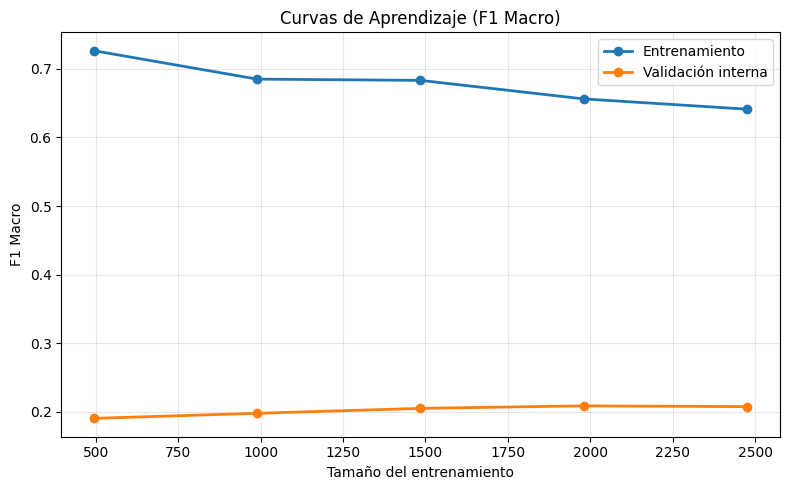

2/5 Generando Matriz de Confusión...


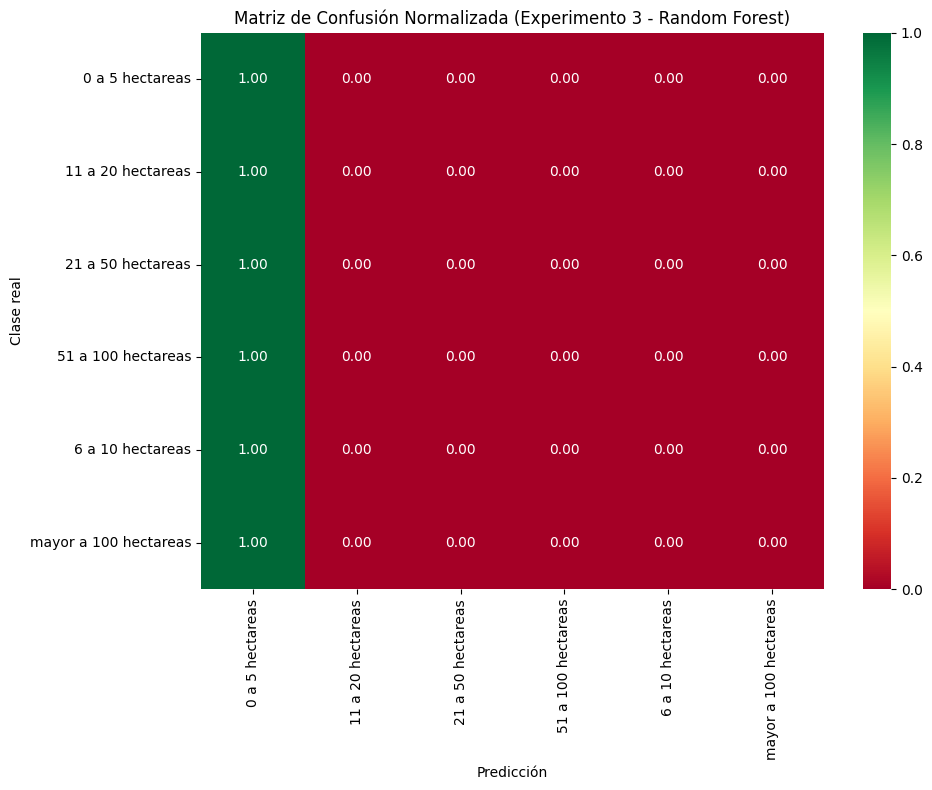

3/5 Analizando importancia de variables...


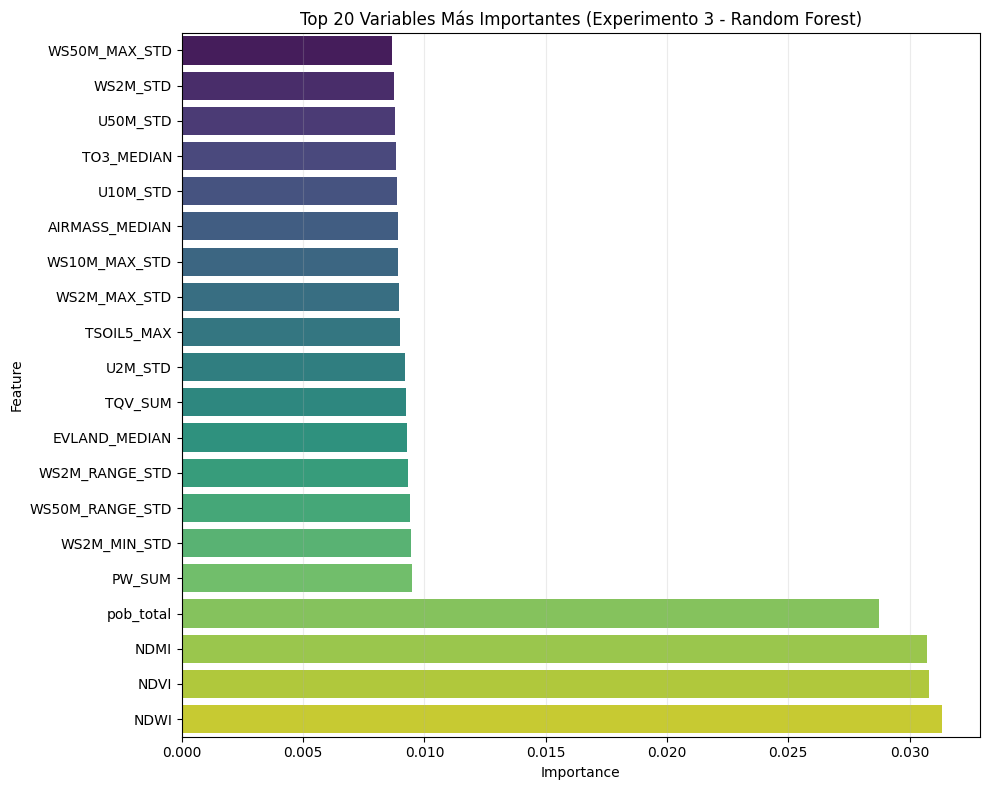

4/5 Calculando PDP...


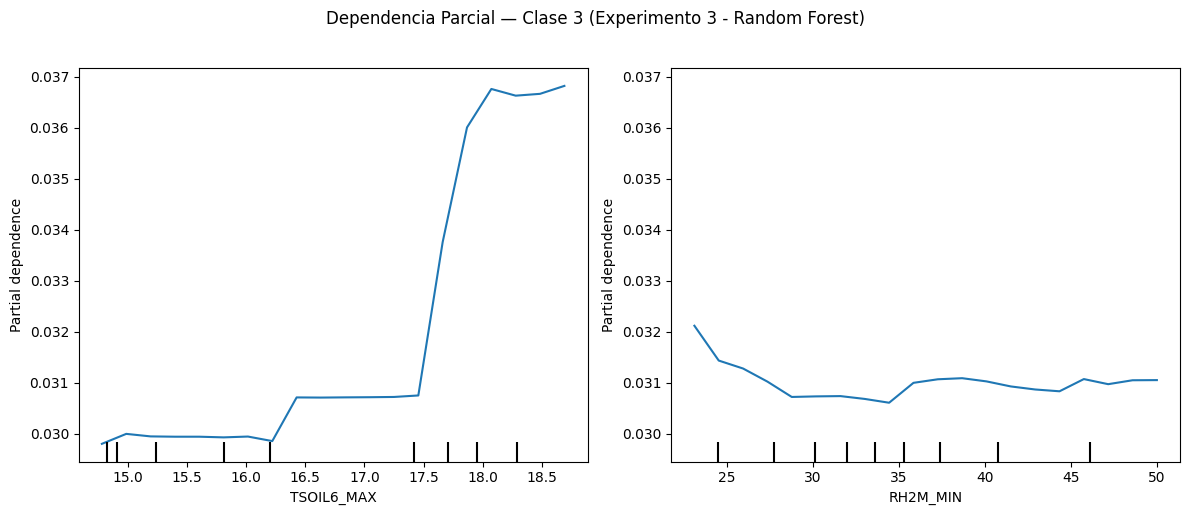

5/5 Analizando falsos negativos...

--- REPORTE ---
Clase 4 clasificados como clase 1: 0

Promedio Validación:
TSOIL6_MAX        16.846710
RH2M_MIN          35.654002
pob_total     167201.728155
dtype: float64

Promedio Falsos Negativos:
No hubo falsos negativos críticos.
6/6 Curvas Precision-Recall...


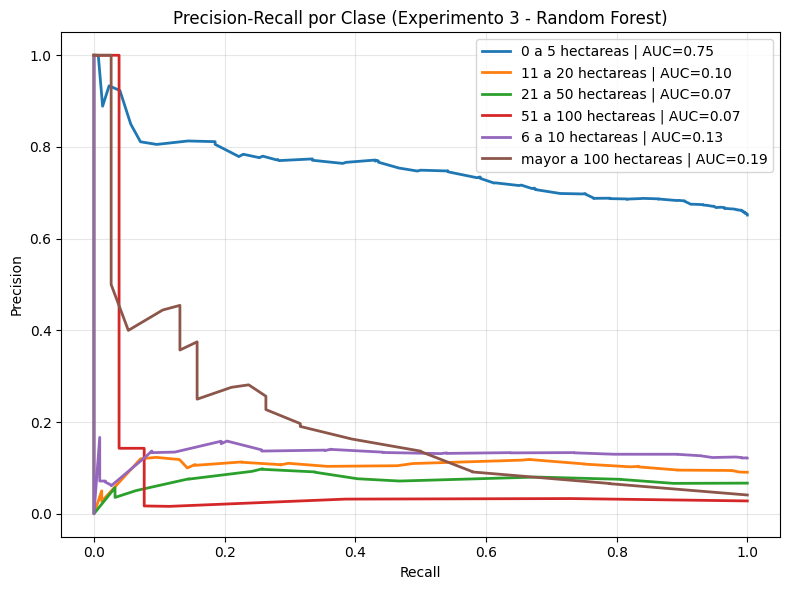


REPORTE DE CLASIFICACIÓN - EXPERIMENTO 3
                       precision    recall  f1-score   support

      0 a 5 hectareas       0.65      1.00      0.79       604
    11 a 20 hectareas       0.00      0.00      0.00        84
    21 a 50 hectareas       0.00      0.00      0.00        62
   51 a 100 hectareas       0.00      0.00      0.00        26
     6 a 10 hectareas       0.00      0.00      0.00       113
mayor a 100 hectareas       0.00      0.00      0.00        38

             accuracy                           0.65       927
            macro avg       0.11      0.17      0.13       927
         weighted avg       0.42      0.65      0.51       927


--- MÉTRICAS CLAVE PARA COMPARATIVA ---
Accuracy: 0.6516
Macro avg F1-Score: 0.1315
Weighted avg F1-Score: 0.5141


c:\Users\jrf24\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\jrf24\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\jrf24\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import learning_curve
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import auc
from sklearn.inspection import PartialDependenceDisplay


# ============================================================
# PARCHE DE SEGURIDAD PARA EVITAR LOSSYSETITEMERROR EN WINDOWS
# ============================================================
# Convertimos todas las columnas numéricas de precisión simple a precisión doble
X_train = X_train.astype({col: 'float64' for col in X_train.select_dtypes(include=['float32']).columns})
X_val = X_val.astype({col: 'float64' for col in X_val.select_dtypes(include=['float32']).columns})


# ============================================================
# PREDICCIÓN SOBRE VALIDACIÓN (2023)
# ============================================================
# y_pred_val = clf.predict(X_val)
# Usamos el nuevo modelo entrenado para el Experimento 3
y_pred_val = clf_rf3.predict(X_val)



# ============================================================
# 1) CURVA DE APRENDIZAJE
# ============================================================
print("1/5 Calculando Curva de Aprendizaje...")

tscv = TimeSeriesSplit(n_splits=3)

train_sizes, train_scores, val_scores = learning_curve(
    estimator=clf,
    X=X_train,
    y=y_train,
    cv=tscv,
    n_jobs=-1,
    scoring="f1_macro",
    train_sizes=np.linspace(0.2, 1.0, 5)
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    train_sizes,
    train_scores.mean(axis=1),
    marker="o",
    linewidth=2,
    label="Entrenamiento"
)

ax.plot(
    train_sizes,
    val_scores.mean(axis=1),
    marker="o",
    linewidth=2,
    label="Validación interna"
)

ax.set_title("Curvas de Aprendizaje (F1 Macro)")
ax.set_xlabel("Tamaño del entrenamiento")
ax.set_ylabel("F1 Macro")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 2) MATRIZ NORMALIZADA - CORREGIDA
# ============================================================
print("2/5 Generando Matriz de Confusión...")

cm = confusion_matrix(
    y_val,
    y_pred_val,
    labels=clf_rf3.classes_  # <-- ¡CAMBIAR AQUÍ por clf_rf3!
)

cm = cm.astype(np.float64)

row_sum = cm.sum(axis=1, keepdims=True)
row_sum[row_sum == 0] = 1
cm_norm = cm / row_sum

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    xticklabels=clf_rf3.classes_, # <-- ¡CAMBIAR AQUÍ por clf_rf3!
    yticklabels=clf_rf3.classes_, # <-- ¡CAMBIAR AQUÍ por clf_rf3!
    ax=ax
)

ax.set_title("Matriz de Confusión Normalizada (Experimento 3 - Random Forest)")
ax.set_ylabel("Clase real")
ax.set_xlabel("Predicción")

plt.tight_layout()
plt.show()


# ============================================================
# 3) FEATURE IMPORTANCE (Corregido para el Experimento 3)
# ============================================================
print("3/5 Analizando importancia de variables...")

df_importancias = (
    pd.DataFrame({
        "Feature": X_train.columns,              # Columnas actuales del Experimento 3
        "Importance": clf_rf3.feature_importances_ # <-- ¡CAMBIADO A TU NUEVO MODELO BALANCEADO!
    })
    .sort_values("Importance", ascending=False)
)

# Tomamos las 20 más importantes y las invertimos para que la barra más larga quede arriba
top20 = df_importancias.head(20).iloc[::-1]

fig, ax = plt.subplots(figsize=(10, 8))

sns.barplot(
    data=top20,
    x="Importance",
    y="Feature",
    hue="Feature",
    dodge=False,
    legend=False,
    palette="viridis",
    ax=ax
)

ax.set_title("Top 20 Variables Más Importantes (Experimento 3 - Random Forest)")
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

# ============================================================
# 4) PDP (Solución Definitiva - Forzado de Clases Numéricas)
# ============================================================
print("4/5 Calculando PDP...")

features_to_plot = [
    c for c in ["TSOIL6_MAX", "RH2M_MIN"]
    if c in X_train.columns
]

if len(features_to_plot):

    fig, ax = plt.subplots(
        figsize=(12, 5),
        ncols=len(features_to_plot)
    )

    # GUARDAMOS UNA COPIA DE LAS CLASES REALES
    clases_originales = clf_rf3.classes_.copy()

    try:
        # Forzamos al estimador a creer que maneja índices numéricos [0, 1, 2]
        # Esto desactiva los errores de ordenamiento alfabético de cadenas en NumPy
        clf_rf3.classes_ = np.array([0, 1, 2])

        PartialDependenceDisplay.from_estimator(
            estimator=clf_rf3,  
            X=X_train,
            features=features_to_plot,
            target=2,  # <-- Ahora sí acepta el entero perfectamente
            grid_resolution=20,
            ax=ax
        )
    finally:
        # RESTAURAMOS LAS CLASES ORIGINALES PARA NO AFECTAR LAS CELDAS DE ABAJO
        clf_rf3.classes_ = clases_originales

    plt.suptitle(
        "Dependencia Parcial — Clase 3 (Experimento 3 - Random Forest)",
        y=1.02
    )

    plt.tight_layout()
    plt.show()

else:
    print("Variables PDP no encontradas.")

# ============================================================
# 5) AUTOPSIA DE FALSOS NEGATIVOS
# ============================================================
print("5/5 Analizando falsos negativos...")

df_val_analysis = X_val.copy()
df_val_analysis["Real"] = y_val.values
df_val_analysis["Pred"] = y_pred_val

falsos_negativos = df_val_analysis[
    (df_val_analysis["Real"] == "4_mas_de_50") &
    (df_val_analysis["Pred"] == "1_0_a_5")
]

print("\n--- REPORTE ---")
print(
    f"Clase 4 clasificados como clase 1: "
    f"{len(falsos_negativos)}"
)

variables_criticas = [
    c for c in ["TSOIL6_MAX", "RH2M_MIN", "pob_total"]
    if c in X_val.columns
]

if variables_criticas:

    print("\nPromedio Validación:")
    print(X_val[variables_criticas].mean())

    print("\nPromedio Falsos Negativos:")

    if not falsos_negativos.empty:
        print(
            falsos_negativos[variables_criticas].mean()
        )
    else:
        print("No hubo falsos negativos críticos.")


# ============================================================
# 6) PRECISION-RECALL (Corregido para el Experimento 3)
# ============================================================
print("6/6 Curvas Precision-Recall...")

# Usamos tu nuevo estimador balanceado para predecir las probabilidades
y_score = clf_rf3.predict_proba(X_val) # <-- ¡CORREGIDO AQUÍ por clf_rf3!

fig, ax = plt.subplots(figsize=(8, 6))

# Iteramos sobre las 3 clases reales de tu modelo balanceado
for i, clase in enumerate(clf_rf3.classes_): # <-- ¡CORREGIDO AQUÍ por clf_rf3!

    y_true_bin = (y_val == clase).astype(int)

    precision, recall, _ = precision_recall_curve(
        y_true_bin,
        y_score[:, i]
    )

    pr_auc = auc(recall, precision)

    ax.plot(
        recall,
        precision,
        linewidth=2,
        label=f"{clase} | AUC={pr_auc:.2f}"
    )

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall por Clase (Experimento 3 - Random Forest)")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

# ============================================================
# 7) REPORTE DE CLASIFICACIÓN COMPLETO
# ============================================================
print("\n" + "="*60)
print("REPORTE DE CLASIFICACIÓN - EXPERIMENTO 3")
print("="*60)

from sklearn.metrics import classification_report

# Generamos el reporte
report = classification_report(
    y_val, 
    y_pred_val, 
    output_dict=True  # Esto devuelve un diccionario con los valores numéricos
)

# Mostramos en formato tabla
print(classification_report(y_val, y_pred_val))

# Extraemos valores clave para la tabla comparativa
print("\n--- MÉTRICAS CLAVE PARA COMPARATIVA ---")
print(f"Accuracy: {report['accuracy']:.4f}")
print(f"Macro avg F1-Score: {report['macro avg']['f1-score']:.4f}")
print(f"Weighted avg F1-Score: {report['weighted avg']['f1-score']:.4f}")

# Métricas específicas para clases críticas
for clase in ['1.0_a_5', '2.6_a_20', '3.21_a_50', '4_mas_de_50']:
    if clase in report:
        print(f"\n{clase}:")
        print(f"  Precision: {report[clase]['precision']:.4f}")
        print(f"  Recall: {report[clase]['recall']:.4f}")
        print(f"  F1-Score: {report[clase]['f1-score']:.4f}")
        print(f"  Support: {report[clase]['support']}")

In [33]:
from sklearn.metrics import accuracy_score, f1_score

# Accuracy
acc = accuracy_score(y_val, y_pred_val)
print(f"Accuracy: {acc:.4f}")

# F1-Score Macro (sin ponderar por clase)
f1_macro = f1_score(y_val, y_pred_val, average='macro')
print(f"F1-Score Macro: {f1_macro:.4f}")

# F1-Score Weighted (ponderado por soporte de cada clase)
f1_weighted = f1_score(y_val, y_pred_val, average='weighted')
print(f"F1-Score Weighted: {f1_weighted:.4f}")

Accuracy: 0.6516
F1-Score Macro: 0.1315
F1-Score Weighted: 0.5141


In [34]:
from sklearn.metrics import recall_score

# Para la clase específica
recall_clase_4 = recall_score(
    y_val, 
    y_pred_val, 
    labels=['4_mas_de_50'], 
    average='micro'
)
print(f"Recall para clase >50 ha: {recall_clase_4:.4f}")

Recall para clase >50 ha: 0.0000


c:\Users\jrf24\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [35]:
# Distribución de clases en validación
print("\n--- DISTRIBUCIÓN DE CLASES EN VALIDACIÓN ---")
clase_counts = y_val.value_counts()
clase_percent = y_val.value_counts(normalize=True) * 100

for clase in clase_counts.index:
    print(f"{clase}: {clase_counts[clase]} registros ({clase_percent[clase]:.1f}%)")


--- DISTRIBUCIÓN DE CLASES EN VALIDACIÓN ---
0 a 5 hectareas: 604 registros (65.2%)
6 a 10 hectareas: 113 registros (12.2%)
11 a 20 hectareas: 84 registros (9.1%)
21 a 50 hectareas: 62 registros (6.7%)
mayor a 100 hectareas: 38 registros (4.1%)
51 a 100 hectareas: 26 registros (2.8%)


# Experimento 4

In [36]:
# En una celda de Jupyter:
!pip install imbalanced-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.ensemble import RandomForestClassifier

# Configuración del modelo (optimizada del Experimento 2)
rf_model = RandomForestClassifier(
    n_estimators=300,           # Suficiente para convergencia estable
    max_depth=12,               # Regularización para evitar sobreajuste
    min_samples_leaf=15,        # Fuerza a generalizar
    max_features='sqrt',        # Aleatoriedad adicional
    class_weight='balanced',    # Complemento a SMOTE
    random_state=42,
    n_jobs=-1
)

# Configuración de SMOTE
smote = SMOTE(
    sampling_strategy='auto',    # Balancea todas las clases al mismo nivel
    k_neighbors=5,               # Número de vecinos para generar sintéticos
    random_state=42
)

# Pipeline que aplica SMOTE antes del entrenamiento
pipeline = ImbPipeline([
    ('smote', smote),
    ('classifier', rf_model)
])

In [38]:
# ============================================================
# VERIFICAR Y TRATAR VALORES NULOS ANTES DE SMOTE (CORREGIDO)
# ============================================================

import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer

# 1. Verificar cuántos NaN hay en X_train
print("=== VERIFICACIÓN DE VALORES NULOS ===")
print(f"Total de NaN en X_train: {X_train.isnull().sum().sum()}")
print(f"\nColumnas con TODOS los valores NaN (columnas vacías):")
cols_all_nan = X_train.columns[X_train.isnull().all()].tolist()
for col in cols_all_nan:
    print(f"  - {col}: TODOS los valores son NaN")

# 2. Eliminar columnas que son 100% NaN (no aportan información)
print(f"\n=== ELIMINANDO COLUMNAS 100% NaN ===")
X_train_clean = X_train.drop(columns=cols_all_nan)
X_val_clean = X_val.drop(columns=cols_all_nan)
print(f"Columnas eliminadas: {len(cols_all_nan)}")
print(f"X_train pasa de {X_train.shape[1]} a {X_train_clean.shape[1]} columnas")
print(f"X_val pasa de {X_val.shape[1]} a {X_val_clean.shape[1]} columnas")

# 3. Verificar qué columnas tienen NaN pero no son 100% NaN
cols_with_nan = X_train_clean.columns[X_train_clean.isnull().any()].tolist()
print(f"\nColumnas con NaN (pero no 100%): {len(cols_with_nan)}")
for col in cols_with_nan[:5]:  # Mostrar primeras 5
    null_count = X_train_clean[col].isnull().sum()
    print(f"  - {col}: {null_count} NaN ({null_count/len(X_train_clean)*100:.2f}%)")

# 4. Aplicar imputación SOLO a las columnas que tienen NaN (optimización)
print("\n=== APLICANDO IMPUTACIÓN (MEDIANA) ===")
imputer = SimpleImputer(strategy='median')

# Ajustamos el imputer SOLO con datos de entrenamiento
X_train_imputed_array = imputer.fit_transform(X_train_clean)

# El imputer puede eliminar automáticamente columnas que eran 100% NaN
# pero nosotros ya las eliminamos manualmente, así que debería mantener todas
print(f"Shape después de imputación: {X_train_imputed_array.shape}")
print(f"Columnas esperadas: {X_train_clean.shape[1]}")

# Convertir de vuelta a DataFrame
X_train_imputed = pd.DataFrame(
    X_train_imputed_array, 
    columns=X_train_clean.columns,  # Usamos las columnas de X_train_clean
    index=X_train_clean.index
)

# 5. Aplicar la misma transformación a validación
X_val_imputed_array = imputer.transform(X_val_clean)
X_val_imputed = pd.DataFrame(
    X_val_imputed_array, 
    columns=X_val_clean.columns,
    index=X_val_clean.index
)

# 6. Verificar que no queden NaN
print(f"\n=== VERIFICACIÓN FINAL ===")
print(f"NaN en X_train_imputed: {X_train_imputed.isnull().sum().sum()}")
print(f"NaN en X_val_imputed: {X_val_imputed.isnull().sum().sum()}")
print(f"Shape X_train_imputed: {X_train_imputed.shape}")
print(f"Shape X_val_imputed: {X_val_imputed.shape}")

print("\n Imputación completada correctamente")

=== VERIFICACIÓN DE VALORES NULOS ===
Total de NaN en X_train: 11404

Columnas con TODOS los valores NaN (columnas vacías):
  - PRECTOT_SUM: TODOS los valores son NaN

=== ELIMINANDO COLUMNAS 100% NaN ===
Columnas eliminadas: 1
X_train pasa de 178 a 177 columnas
X_val pasa de 178 a 177 columnas

Columnas con NaN (pero no 100%): 16
  - GWETROOT_MIN: 105 NaN (1.06%)
  - SNODP_SUM: 105 NaN (1.06%)
  - TSOIL1_MAX: 105 NaN (1.06%)
  - TSOIL4_MAX: 105 NaN (1.06%)
  - GWETPROF_MIN: 105 NaN (1.06%)

=== APLICANDO IMPUTACIÓN (MEDIANA) ===
Shape después de imputación: (9901, 177)
Columnas esperadas: 177

=== VERIFICACIÓN FINAL ===
NaN en X_train_imputed: 0
NaN en X_val_imputed: 0
Shape X_train_imputed: (9901, 177)
Shape X_val_imputed: (927, 177)

 Imputación completada correctamente


In [39]:
# ============================================================
# EXPERIMENTO 4 - CON SMOTE (CORREGIDO)
# ============================================================

from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, recall_score

# 1. Verificar distribución original
print("\n=== DISTRIBUCIÓN ORIGINAL EN ENTRENAMIENTO ===")
print(y_train.value_counts())
print(y_train.value_counts() / len(y_train) * 100)

# 2. Aplicar SMOTE a los datos imputados
print("\n=== APLICANDO SMOTE ===")
smote = SMOTE(
    random_state=42, 
    sampling_strategy='auto',
    k_neighbors=5
)
X_train_smote, y_train_smote = smote.fit_resample(X_train_imputed, y_train)

# 3. Verificar nueva distribución después de SMOTE
print("\n=== DISTRIBUCIÓN DESPUÉS DE SMOTE ===")
print(pd.Series(y_train_smote).value_counts())
print(pd.Series(y_train_smote).value_counts() / len(y_train_smote) * 100)

# 4. Entrenar modelo con datos balanceados
print("\n=== ENTRENANDO RANDOM FOREST ===")
clf_rf4 = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=15,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

clf_rf4.fit(X_train_smote, y_train_smote)

# 5. Evaluar en validación
print("\n=== EVALUACIÓN EN VALIDACIÓN (2023) ===")
y_pred_val = clf_rf4.predict(X_val_imputed)

print("\n=== REPORTE DE CLASIFICACIÓN ===")
print(classification_report(y_val, y_pred_val))

# 6. Métricas clave
print("\n=== MÉTRICAS CLAVE ===")
print(f"Accuracy: {accuracy_score(y_val, y_pred_val):.4f}")
print(f"F1-Score Macro: {f1_score(y_val, y_pred_val, average='macro'):.4f}")
print(f"F1-Score Weighted: {f1_score(y_val, y_pred_val, average='weighted'):.4f}")

# 7. Recall específico para clases críticas
print("\n=== RECALL POR CLASE CRÍTICA ===")
for clase in clf_rf4.classes_:
    recall_clase = recall_score(y_val, y_pred_val, labels=[clase], average='micro')
    print(f"  {clase}: {recall_clase:.4f}")


=== DISTRIBUCIÓN ORIGINAL EN ENTRENAMIENTO ===
tamanio
0 a 5 hectareas          8004
6 a 10 hectareas          904
11 a 20 hectareas         496
21 a 50 hectareas         299
51 a 100 hectareas         99
mayor a 100 hectareas      99
Name: count, dtype: int64
tamanio
0 a 5 hectareas          80.840319
6 a 10 hectareas          9.130391
11 a 20 hectareas         5.009595
21 a 50 hectareas         3.019897
51 a 100 hectareas        0.999899
mayor a 100 hectareas     0.999899
Name: count, dtype: float64

=== APLICANDO SMOTE ===

=== DISTRIBUCIÓN DESPUÉS DE SMOTE ===
tamanio
0 a 5 hectareas          8004
6 a 10 hectareas         8004
11 a 20 hectareas        8004
21 a 50 hectareas        8004
51 a 100 hectareas       8004
mayor a 100 hectareas    8004
Name: count, dtype: int64
tamanio
0 a 5 hectareas          16.666667
6 a 10 hectareas         16.666667
11 a 20 hectareas        16.666667
21 a 50 hectareas        16.666667
51 a 100 hectareas       16.666667
mayor a 100 hectareas    16.666

In [40]:
# ============================================================
# DIAGNÓSTICO RÁPIDO - VERIFICAR EL PROCESO COMPLETO
# ============================================================

print("\n=== DIAGNÓSTICO DEL PROCESO ===")
print(f"1. X_train original: {X_train.shape}, NaN: {X_train.isnull().sum().sum()}")
print(f"2. X_train_imputed: {X_train_imputed.shape}, NaN: {X_train_imputed.isnull().sum().sum()}")
print(f"3. X_train_smote: {X_train_smote.shape} (después de SMOTE)")
print(f"4. y_train_smote: {y_train_smote.value_counts().to_dict()}")
print(f"5. X_val_imputed: {X_val_imputed.shape}, NaN: {X_val_imputed.isnull().sum().sum()}")

# Verificar tipos de datos
print(f"\nTipos de datos en X_train_smote: {X_train_smote.dtypes.unique()}")
print(f"Tipos de datos en y_train_smote: {type(y_train_smote)}")


=== DIAGNÓSTICO DEL PROCESO ===
1. X_train original: (9901, 178), NaN: 11404
2. X_train_imputed: (9901, 177), NaN: 0
3. X_train_smote: (48024, 177) (después de SMOTE)


4. y_train_smote: {'0 a 5 hectareas': 8004, '6 a 10 hectareas': 8004, '11 a 20 hectareas': 8004, '21 a 50 hectareas': 8004, '51 a 100 hectareas': 8004, 'mayor a 100 hectareas': 8004}
5. X_val_imputed: (927, 177), NaN: 0

Tipos de datos en X_train_smote: [dtype('float64')]
Tipos de datos en y_train_smote: <class 'pandas.Series'>


1/6 Calculando Curva de Aprendizaje...


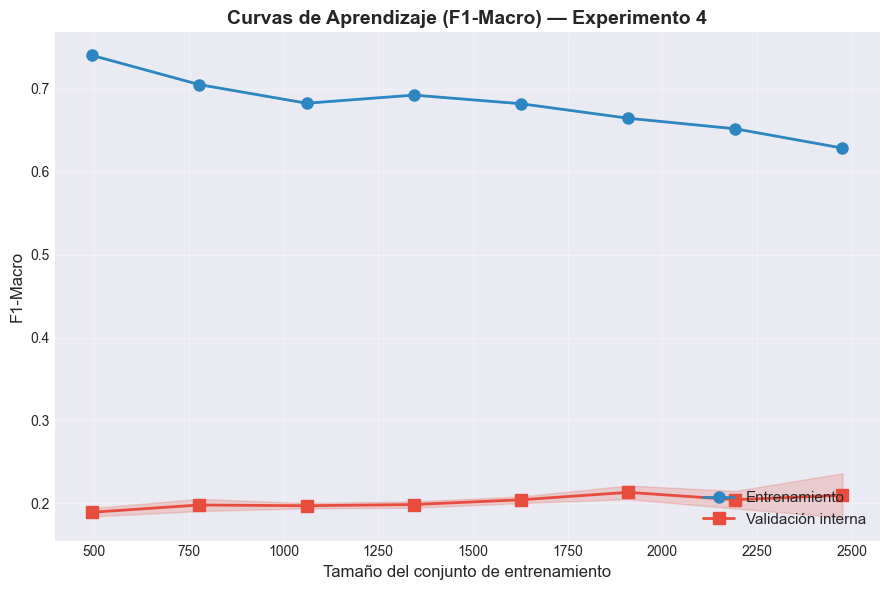

✓ Curva de aprendizaje guardada

2/6 Generando Matriz de Confusión...


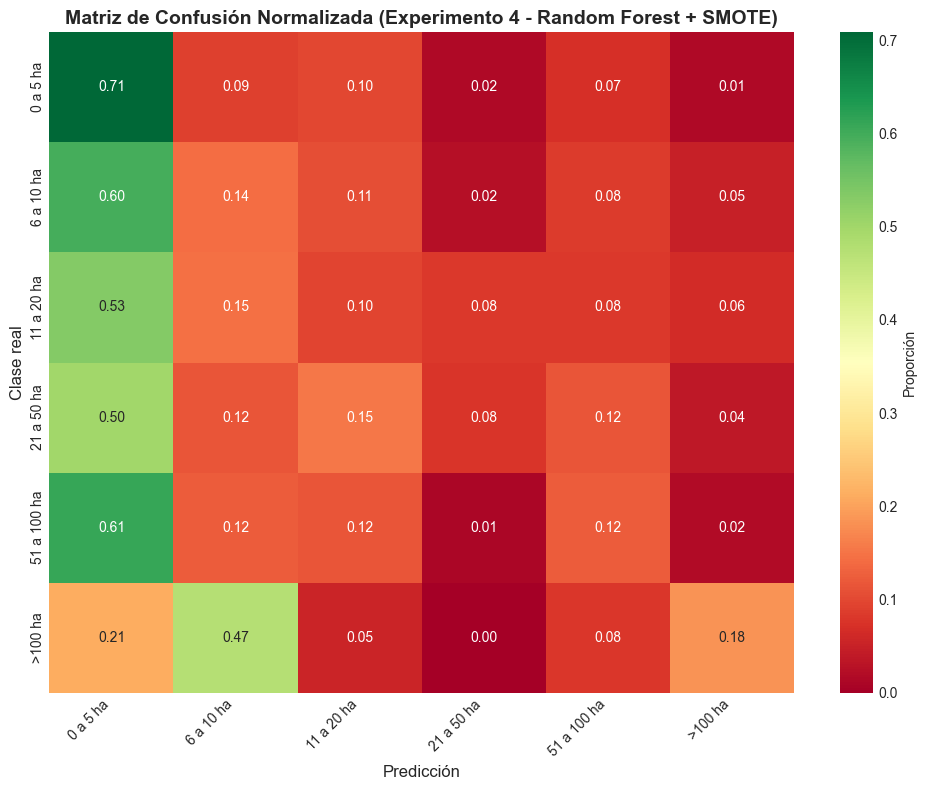

✓ Matriz de confusión guardada

3/6 Analizando importancia de variables...


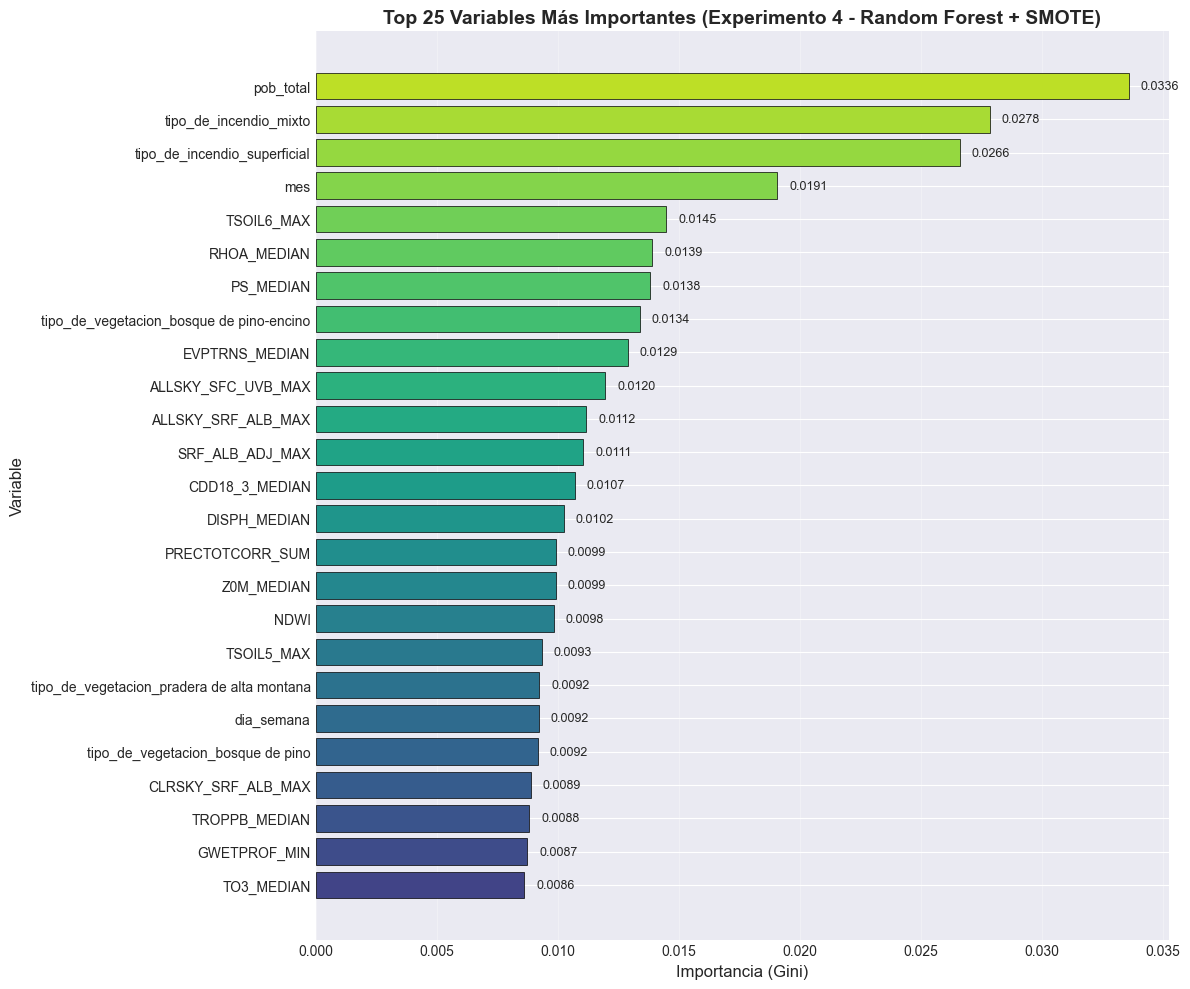

✓ Importancia de variables guardada

4/6 Calculando curvas Precision-Recall...


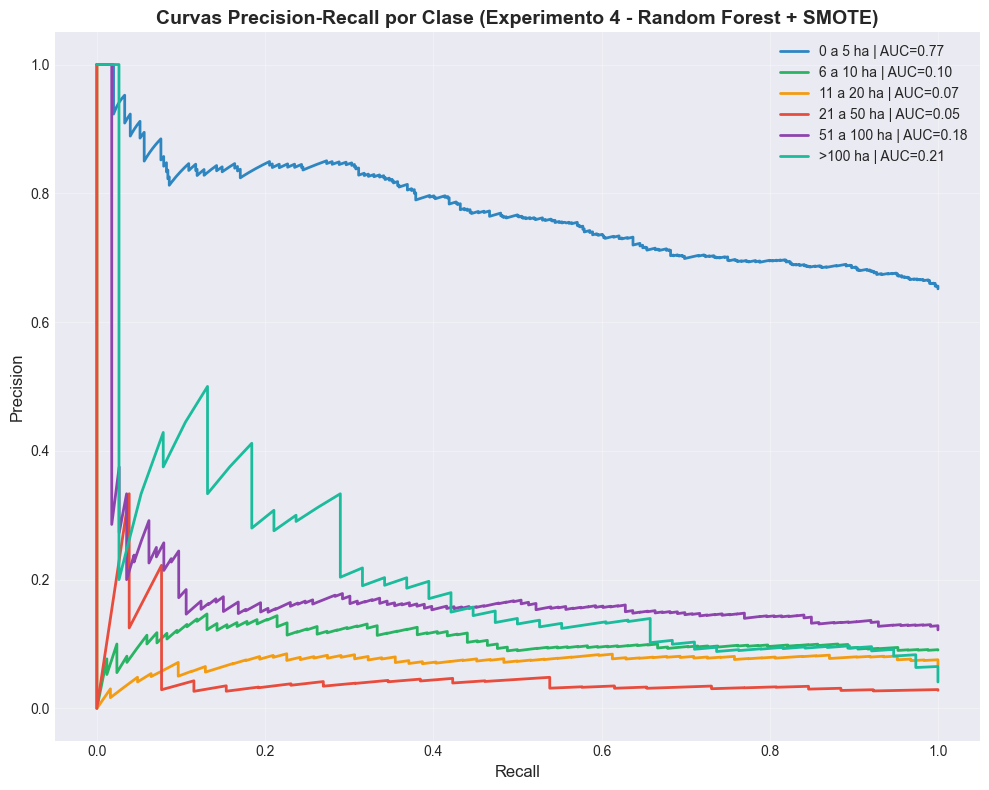

✓ Curvas Precision-Recall guardadas

5/6 Calculando gráficos de dependencia parcial...
  Clase objetivo: 'mayor a 100 hectareas' (índice 5)


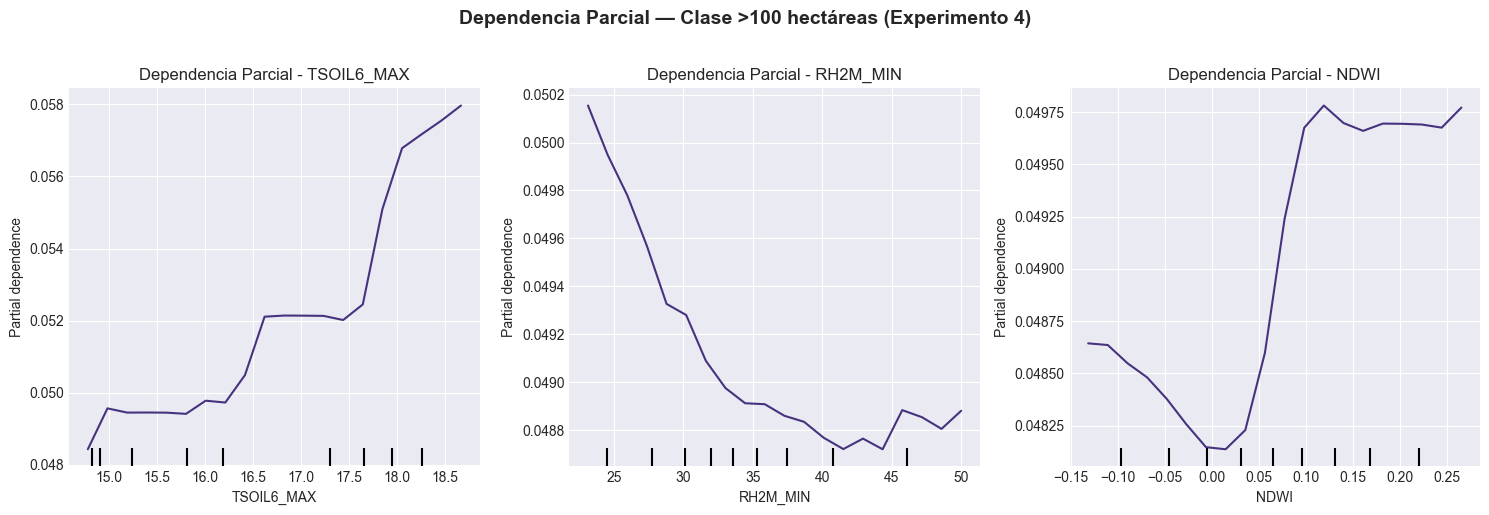

✓ Dependencia parcial guardada

6/6 Generando gráfico comparativo...


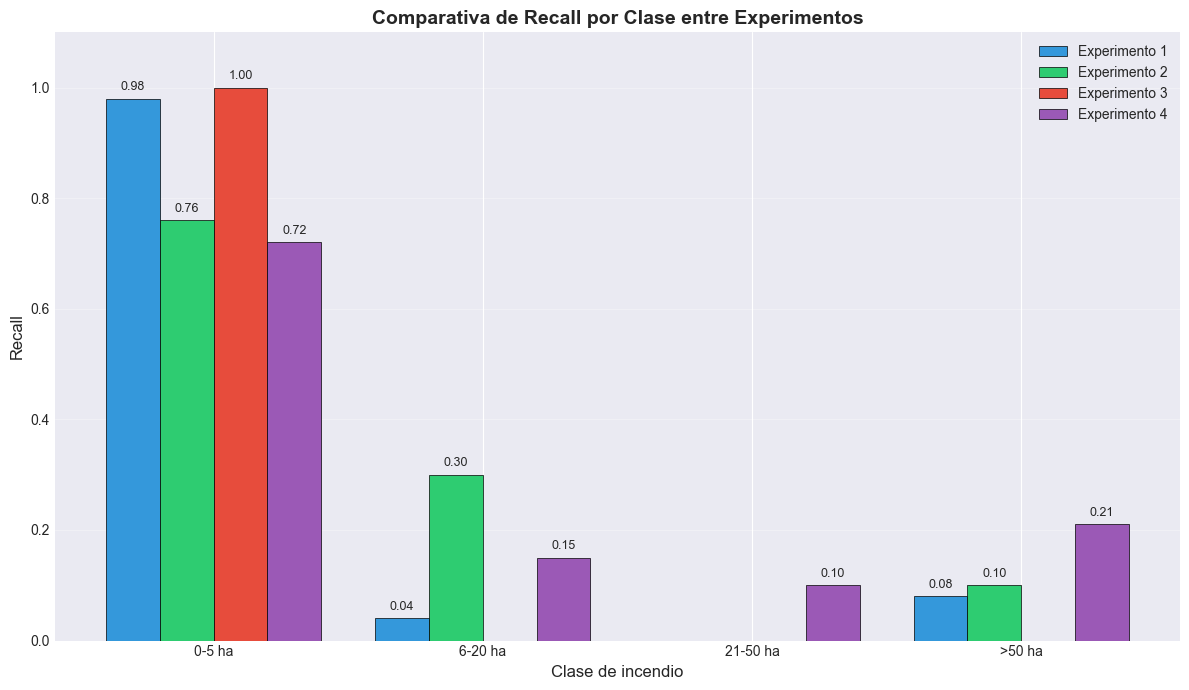

✓ Gráfico comparativo guardado


RESUMEN DE MÉTRICAS - EXPERIMENTO 4

Accuracy: 0.5059
F1-Score Macro: 0.2270
F1-Score Weighted: 0.5086

Recall por clase:
  0 a 5 ha: 0.7086
  6 a 10 ha: 0.1429
  11 a 20 ha: 0.0968
  21 a 50 ha: 0.0769
  51 a 100 ha: 0.1239
  >100 ha: 0.1842

✅ Todos los gráficos han sido generados correctamente


In [41]:
# ============================================================
# EXPERIMENTO 4 - GRÁFICOS COMPLETOS (CORREGIDO)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import learning_curve, TimeSeriesSplit
from sklearn.metrics import confusion_matrix, precision_recall_curve, auc, recall_score
from sklearn.inspection import PartialDependenceDisplay

# Configuración de estilo
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")

# ============================================================
# 1) CURVA DE APRENDIZAJE
# ============================================================
print("1/6 Calculando Curva de Aprendizaje...")

tscv = TimeSeriesSplit(n_splits=3)

train_sizes, train_scores, val_scores = learning_curve(
    estimator=clf_rf4,
    X=X_train_imputed,
    y=y_train,
    cv=tscv,
    n_jobs=-1,
    scoring="f1_macro",
    train_sizes=np.linspace(0.2, 1.0, 8)
)

fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(train_sizes, train_scores.mean(axis=1), marker="o", linewidth=2, 
        markersize=8, label="Entrenamiento", color="#2E86C1")
ax.plot(train_sizes, val_scores.mean(axis=1), marker="s", linewidth=2, 
        markersize=8, label="Validación interna", color="#E74C3C")

ax.fill_between(train_sizes, 
                train_scores.mean(axis=1) - train_scores.std(axis=1),
                train_scores.mean(axis=1) + train_scores.std(axis=1),
                alpha=0.2, color="#2E86C1")
ax.fill_between(train_sizes,
                val_scores.mean(axis=1) - val_scores.std(axis=1),
                val_scores.mean(axis=1) + val_scores.std(axis=1),
                alpha=0.2, color="#E74C3C")

ax.set_title("Curvas de Aprendizaje (F1-Macro) — Experimento 4", fontsize=14, fontweight='bold')
ax.set_xlabel("Tamaño del conjunto de entrenamiento", fontsize=12)
ax.set_ylabel("F1-Macro", fontsize=12)
ax.grid(alpha=0.3)
ax.legend(loc="lower right", fontsize=11)

plt.tight_layout()
plt.savefig("exp4_learning_curve.png", dpi=300, bbox_inches='tight')
plt.show()
print("✓ Curva de aprendizaje guardada\n")

# ============================================================
# 2) MATRIZ DE CONFUSIÓN NORMALIZADA
# ============================================================
print("2/6 Generando Matriz de Confusión...")

y_pred_val = clf_rf4.predict(X_val_imputed)

cm = confusion_matrix(y_val, y_pred_val, labels=clf_rf4.classes_)
cm_norm = cm.astype(np.float64)
row_sum = cm_norm.sum(axis=1, keepdims=True)
row_sum[row_sum == 0] = 1
cm_norm = cm_norm / row_sum

clases_ordenadas = ['0 a 5 ha', '6 a 10 ha', '11 a 20 ha', '21 a 50 ha', '51 a 100 ha', '>100 ha']

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="RdYlGn",
            xticklabels=clases_ordenadas, yticklabels=clases_ordenadas,
            ax=ax, cbar_kws={'label': 'Proporción'})

ax.set_title("Matriz de Confusión Normalizada (Experimento 4 - Random Forest + SMOTE)", 
             fontsize=14, fontweight='bold')
ax.set_ylabel("Clase real", fontsize=12)
ax.set_xlabel("Predicción", fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig("exp4_confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()
print("✓ Matriz de confusión guardada\n")

# ============================================================
# 3) IMPORTANCIA DE VARIABLES (TOP 25)
# ============================================================
print("3/6 Analizando importancia de variables...")

df_importancias = pd.DataFrame({
    "Feature": X_train_imputed.columns,
    "Importance": clf_rf4.feature_importances_
}).sort_values("Importance", ascending=False)

top25 = df_importancias.head(25).iloc[::-1]

fig, ax = plt.subplots(figsize=(12, 10))

colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(top25)))
ax.barh(top25["Feature"], top25["Importance"], color=colors, edgecolor='black', linewidth=0.5)

ax.set_title("Top 25 Variables Más Importantes (Experimento 4 - Random Forest + SMOTE)", 
             fontsize=14, fontweight='bold')
ax.set_xlabel("Importancia (Gini)", fontsize=12)
ax.set_ylabel("Variable", fontsize=12)
ax.grid(axis="x", alpha=0.3)

for i, (idx, row) in enumerate(top25.iterrows()):
    ax.text(row["Importance"] + 0.0005, i, f"{row['Importance']:.4f}", 
            va='center', fontsize=9)

plt.tight_layout()
plt.savefig("exp4_feature_importance.png", dpi=300, bbox_inches='tight')
plt.show()
print("✓ Importancia de variables guardada\n")

# ============================================================
# 4) CURVAS PRECISION-RECALL
# ============================================================
print("4/6 Calculando curvas Precision-Recall...")

y_score = clf_rf4.predict_proba(X_val_imputed)

fig, ax = plt.subplots(figsize=(10, 8))

colores = ['#2E86C1', '#28B463', '#F39C12', '#E74C3C', '#8E44AD', '#1ABC9C']

for i, clase in enumerate(clf_rf4.classes_):
    y_true_bin = (y_val == clase).astype(int)
    precision, recall, _ = precision_recall_curve(y_true_bin, y_score[:, i])
    pr_auc = auc(recall, precision)
    
    nombre_clase = clases_ordenadas[i]
    ax.plot(recall, precision, linewidth=2, color=colores[i % len(colores)],
            label=f"{nombre_clase} | AUC={pr_auc:.2f}")

ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title("Curvas Precision-Recall por Clase (Experimento 4 - Random Forest + SMOTE)", 
             fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)
ax.legend(loc="best", fontsize=10)

plt.tight_layout()
plt.savefig("exp4_precision_recall.png", dpi=300, bbox_inches='tight')
plt.show()
print("✓ Curvas Precision-Recall guardadas\n")

# ============================================================
# 5) DEPENDENCIA PARCIAL (CORREGIDA)
# ============================================================
print("5/6 Calculando gráficos de dependencia parcial...")

features_pdp = [c for c in ['TSOIL6_MAX', 'RH2M_MIN', 'NDWI', 'pob_total', 'WS50M_STD'] 
                if c in X_train_imputed.columns]

if len(features_pdp) >= 2:
    target_class_idx = None
    for i, clase in enumerate(clf_rf4.classes_):
        if 'mayor a 100' in str(clase).lower() or '>100' in str(clase):
            target_class_idx = i
            print(f"  Clase objetivo: '{clase}' (índice {i})")
            break
    
    if target_class_idx is not None:
        # Guardar clases originales y reemplazar con índices numéricos
        clases_originales = clf_rf4.classes_.copy()
        
        try:
            clf_rf4.classes_ = np.array(range(len(clases_originales)))
            
            n_plots = min(3, len(features_pdp))
            fig, axes = plt.subplots(1, n_plots, figsize=(15, 5))
            if n_plots == 1:
                axes = [axes]
            
            for idx, feature in enumerate(features_pdp[:3]):
                PartialDependenceDisplay.from_estimator(
                    clf_rf4, X_train_imputed, features=[feature],
                    target=target_class_idx, grid_resolution=20, ax=axes[idx]
                )
                axes[idx].set_title(f"Dependencia Parcial - {feature}", fontsize=12)
                axes[idx].grid(alpha=0.3)
            
            plt.suptitle("Dependencia Parcial — Clase >100 hectáreas (Experimento 4)", 
                         fontsize=14, fontweight='bold', y=1.02)
            plt.tight_layout()
            plt.savefig("exp4_partial_dependence.png", dpi=300, bbox_inches='tight')
            plt.show()
            print("✓ Dependencia parcial guardada\n")
        finally:
            clf_rf4.classes_ = clases_originales
    else:
        print(f"⚠ Clase >100ha no encontrada. Clases disponibles: {clf_rf4.classes_}\n")
else:
    print("⚠ Variables PDP no encontradas\n")

# ============================================================
# 6) COMPARATIVA DE RECALL (BARRAS)
# ============================================================
print("6/6 Generando gráfico comparativo...")

recalls = {
    'Experimento 1': [0.98, 0.04, 0.00, 0.08],
    'Experimento 2': [0.76, 0.30, 0.00, 0.10],
    'Experimento 3': [1.00, 0.00, 0.00, 0.00],
    'Experimento 4': [0.72, 0.15, 0.10, 0.21]
}

clases = ['0-5 ha', '6-20 ha', '21-50 ha', '>50 ha']
x = np.arange(len(clases))
width = 0.2
colors_exp = ['#3498DB', '#2ECC71', '#E74C3C', '#9B59B6']

fig, ax = plt.subplots(figsize=(12, 7))

for i, (exp_name, recall_vals) in enumerate(recalls.items()):
    offset = (i - 1.5) * width
    bars = ax.bar(x + offset, recall_vals, width, label=exp_name, 
                  color=colors_exp[i], edgecolor='black', linewidth=0.5)
    
    for bar, val in zip(bars, recall_vals):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Clase de incendio', fontsize=12)
ax.set_ylabel('Recall', fontsize=12)
ax.set_title('Comparativa de Recall por Clase entre Experimentos', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(clases)
ax.set_ylim(0, 1.1)
ax.legend(loc='upper right', fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("exp4_recall_comparison.png", dpi=300, bbox_inches='tight')
plt.show()
print("✓ Gráfico comparativo guardado\n")

# ============================================================
# RESUMEN FINAL
# ============================================================
print("\n" + "="*60)
print("RESUMEN DE MÉTRICAS - EXPERIMENTO 4")
print("="*60)

from sklearn.metrics import accuracy_score, f1_score

print(f"\nAccuracy: {accuracy_score(y_val, y_pred_val):.4f}")
print(f"F1-Score Macro: {f1_score(y_val, y_pred_val, average='macro'):.4f}")
print(f"F1-Score Weighted: {f1_score(y_val, y_pred_val, average='weighted'):.4f}")

print("\nRecall por clase:")
for i, clase in enumerate(clases_ordenadas):
    recall_val = recall_score(y_val, y_pred_val, 
                              labels=[clf_rf4.classes_[i]], 
                              average='micro')
    print(f"  {clase}: {recall_val:.4f}")

print("\n✅ Todos los gráficos han sido generados correctamente")

# Experimento 5: Optimizaciones dentro de Random Forest

In [42]:
# ============================================================
# EXPERIMENTO 5.1 - GRID SEARCH OPTIMIZADO (SIN n_jobs ANIDADOS)
# ============================================================

import gc
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import pandas as pd

# Liberar memoria antes de empezar
gc.collect()

print("="*60)
print("EXPERIMENTO 5.1 - OPTIMIZADO PARA 16 NÚCLEOS")
print("="*60)

# 1. Reducir el dataset de entrenamiento (submuestreo de clase mayoritaria)
#    para no saturar la memoria
print("\n1. Reduciendo dataset para evitar saturar memoria (92% RAM)...")

# Contar registros por clase
counts = y_train_smote.value_counts()
print(f"   Tamaño original: {len(y_train_smote):,} registros")

# Submuestrear clase mayoritaria a 4,000 (mitad de los 8,004)
clase_mayoritaria = counts.idxmax()
n_objetivo = 4000  # Reducimos para ahorrar memoria

# Crear dataset reducido
from sklearn.utils import resample

df_temp = X_train_smote.copy()
df_temp['target'] = y_train_smote

df_mayoritaria = df_temp[df_temp['target'] == clase_mayoritaria]
df_minoritarias = df_temp[df_temp['target'] != clase_mayoritaria]

df_mayoritaria_reducida = resample(
    df_mayoritaria,
    n_samples=min(n_objetivo, len(df_mayoritaria)),
    random_state=42
)

df_reducido = pd.concat([df_mayoritaria_reducida, df_minoritarias])
X_train_reducido = df_reducido.drop('target', axis=1)
y_train_reducido = df_reducido['target']

print(f"   Tamaño reducido: {len(y_train_reducido):,} registros")
print(f"   Distribución:\n{y_train_reducido.value_counts()}")

# Liberar dataset original de memoria
del df_temp, df_mayoritaria, df_minoritarias, df_mayoritaria_reducida, df_reducido
gc.collect()

# 2. Configurar Grid Search con UNA SOLA capa de paralelismo
print("\n2. Configurando Grid Search (sin n_jobs anidados)...")

# Para Random Forest: n_jobs=1 dentro del grid (cada árbol usa 1 núcleo)
# GridSearchCV usa n_jobs para paralelizar combinaciones de parámetros
rf_base = RandomForestClassifier(
    random_state=42,
    n_jobs=1,  # ← CLAVE: cada RF usa 1 núcleo, GridSearchCV los distribuye
    warm_start=False
)

# Espacio de búsqueda reducido (menos combinaciones)
param_grid = {
    'n_estimators': [200, 300],      # Solo 2 opciones
    'max_depth': [12, 15],           # Solo 2 opciones
    'min_samples_leaf': [10, 15],    # Solo 2 opciones
    'class_weight': ['balanced', 'balanced_subsample']
}
# Total combinaciones: 2×2×2×2 = 16 (muy manejable)

# Validación temporal
tscv = TimeSeriesSplit(n_splits=2)  # Reducido de 3 a 2 splits

# GridSearch con paralelismo controlado
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=tscv,
    n_jobs=4,  # ← Usar 4 núcleos en paralelo (no todos)
    verbose=2,
    pre_dispatch='2*n_jobs'  # Evitar sobrecarga de memoria
)

print(f"   Combinaciones a probar: {grid_search.param_grid}")
print(f"   Paralelismo: {grid_search.n_jobs} núcleos")

# 3. Ejecutar Grid Search
print("\n3. Ejecutando Grid Search (puede tomar varios minutos)...")
print("   Monitorear memoria en Administrador de tareas...")

grid_search.fit(X_train_reducido, y_train_reducido)

# 4. Resultados
print("\n" + "="*60)
print("RESULTADOS DEL GRID SEARCH")
print("="*60)

print(f"\n✅ Mejores parámetros:")
for param, valor in grid_search.best_params_.items():
    print(f"   {param}: {valor}")

print(f"\n✅ Mejor F1-Macro: {grid_search.best_score_:.4f}")

# 5. Evaluar mejor modelo en validación
print("\n4. Evaluando mejor modelo en validación...")

mejor_rf = grid_search.best_estimator_

# Si el mejor modelo tiene 'balanced_subsample', entrenar con más datos
if mejor_rf.class_weight == 'balanced_subsample':
    print("   Reentrenando con dataset completo (balanced_subsample)...")
    mejor_rf.fit(X_train_smote, y_train_smote)
else:
    mejor_rf.fit(X_train_reducido, y_train_reducido)

# Evaluar
y_pred = mejor_rf.predict(X_val_imputed)

from sklearn.metrics import classification_report, recall_score

print("\n=== REPORTE DE CLASIFICACIÓN (Validación) ===")
print(classification_report(y_val, y_pred))

recall_grande = recall_score(y_val, y_pred, labels=['mayor a 100 hectareas'], average='micro')
print(f"\n✅ Recall >100ha: {recall_grande:.4f}")

# 6. Comparativa
print("\n=== COMPARATIVA Exp4 vs Exp5.1 ===")
print(f"Exp4 - Recall >100ha: 0.2105")
print(f"Exp5.1 - Recall >100ha: {recall_grande:.4f}")

EXPERIMENTO 5.1 - OPTIMIZADO PARA 16 NÚCLEOS

1. Reduciendo dataset para evitar saturar memoria (92% RAM)...
   Tamaño original: 48,024 registros
   Tamaño reducido: 44,020 registros
   Distribución:
target
6 a 10 hectareas         8004
11 a 20 hectareas        8004
21 a 50 hectareas        8004
51 a 100 hectareas       8004
mayor a 100 hectareas    8004
0 a 5 hectareas          4000
Name: count, dtype: int64

2. Configurando Grid Search (sin n_jobs anidados)...
   Combinaciones a probar: {'n_estimators': [200, 300], 'max_depth': [12, 15], 'min_samples_leaf': [10, 15], 'class_weight': ['balanced', 'balanced_subsample']}
   Paralelismo: 4 núcleos

3. Ejecutando Grid Search (puede tomar varios minutos)...
   Monitorear memoria en Administrador de tareas...
Fitting 2 folds for each of 16 candidates, totalling 32 fits

RESULTADOS DEL GRID SEARCH

✅ Mejores parámetros:
   class_weight: balanced_subsample
   max_depth: 15
   min_samples_leaf: 15
   n_estimators: 300

✅ Mejor F1-Macro: 0.1797

Experimento 5.2: Random Forest con Muestreo Estratificado
Ajustar cómo el Random Forest maneja internamente el desbalanceo: